In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q cdsapi          # CAMS/EAC4 downloads from the Atmosphere Data Store (needs your ADS API key)
!pip install -q boto3           # OpenAQ S3 archive access (no-sign-request bucket)
!pip install -q metar           # parse raw METAR strings into fields (if you pull raw reports, not the IEM CSV)
# requests is preinstalled — used for NOAA/AQICN REST calls

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.9/204.9 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install -q "dask[complete]"   # out-of-core processing so multi-GB data doesn't blow Colab's RAM
!pip install -q pyarrow            # read/write Parquet — your compressed working format
!pip install -q netCDF4 h5netcdf   # NetCDF backends for xarray (EAC4 delivered as NetCDF)
# xarray is preinstalled — the main tool for the EAC4 grids

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.2 MB/s eta 0:00:00


In [ ]:
!pip install -q pyod            # dedicated outlier-detection library: Isolation Forest, ECOD, AutoEncoder, etc.
# scikit-learn, tensorflow/keras, numpy, pandas are all preinstalled

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 860.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install -q shap            # per-reading attribution / trust-score explainability (you used this before)
# matplotlib, seaborn, and sklearn.metrics are preinstalled for ROC/PR curves, confusion matrices

In [ ]:
import cdsapi, boto3, xarray as xr, dask, pyarrow, pyod, shap, sklearn, tensorflow as tf
print("cdsapi, boto3, xarray, dask, pyarrow, pyod, shap OK")
print("sklearn", sklearn.__version__, "| tensorflow", tf.__version__)

cdsapi, boto3, xarray, dask, pyarrow, pyod, shap OK
sklearn 1.6.1 | tensorflow 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, glob, os

PROJECT = "/content/drive/MyDrive/Aerosentinental"
EXT = f"{PROJECT}/extracted"
os.makedirs(EXT, exist_ok=True)

# find the uploaded zip (matches any .zip in the folder)
zips = glob.glob(f"{PROJECT}/*.zip")
print("found zip(s):", zips)

for zpath in zips:
    with zipfile.ZipFile(zpath) as z:
        print(f"\ncontents of {os.path.basename(zpath)}:")
        print(z.namelist())
        z.extractall(EXT)

print("\n.nc files after extraction:")
print(sorted(glob.glob(f"{EXT}/*.nc")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
found zip(s): ['/content/drive/MyDrive/Aerosentinental/8a8bd127bc4ee036c6ad11d2b3d8c2e.zip']

contents of 8a8bd127bc4ee036c6ad11d2b3d8c2e.zip:
['data_sfc.nc']

.nc files after extraction:
['/content/drive/MyDrive/Aerosentinental/extracted/data_sfc.nc']


In [ ]:
import xarray as xr
import pandas as pd
import glob, os

PROJECT = "/content/drive/MyDrive/Aerosentinental"
EXT = f"{PROJECT}/extracted"
PROC = f"{PROJECT}/processed"
os.makedirs(PROC, exist_ok=True)

# --- 1. Open the NetCDF ---
nc_path = f"{EXT}/data_sfc.nc"
ds = xr.open_dataset(nc_path)          # add engine="netcdf4" if it errors
print("=== DATASET OVERVIEW ===")
print(ds)
print("\n=== VARIABLES ===")
for v in ds.data_vars:
    print(f"  {v:15s} {ds[v].attrs.get('long_name','')} [{ds[v].attrs.get('units','')}]")

# --- 2. Detect coordinate names (EAC4 uses latitude/longitude; some exports use lat/lon) ---
lat_name = "latitude" if "latitude" in ds.coords else "lat"
lon_name = "longitude" if "longitude" in ds.coords else "lon"
print(f"\nUsing coords: {lat_name}, {lon_name}")
print("lon range:", float(ds[lon_name].min()), "to", float(ds[lon_name].max()))

# --- 3. Airport coordinates ---
AIRPORTS = {
    "OMAA": {"lat": 24.433, "lon": 54.651},   # Abu Dhabi Intl
    "OMDB": {"lat": 25.253, "lon": 55.364},   # Dubai Intl
}

# EAC4 longitudes are sometimes 0-360; convert airport lon if needed
lon_max = float(ds[lon_name].max())
def fix_lon(lon):
    return lon % 360 if lon_max > 180 else lon

# --- 4. Extract nearest grid cell per airport -> tidy DataFrame ---
frames = []
for code, c in AIRPORTS.items():
    point = ds.sel({lat_name: c["lat"], lon_name: fix_lon(c["lon"])}, method="nearest")
    df = point.to_dataframe().reset_index()
    # keep only time + data variables (drop leftover coord columns)
    keep = ["valid_time"] if "valid_time" in df.columns else (["time"] if "time" in df.columns else [])
    keep += [v for v in ds.data_vars]
    df = df[[col for col in keep if col in df.columns]].copy()
    df.rename(columns={"valid_time": "time"}, inplace=True)
    df["airport"] = code
    df["grid_lat"] = float(point[lat_name].values)
    df["grid_lon"] = float(point[lon_name].values)
    frames.append(df)
    print(f"\n{code}: nearest cell ({float(point[lat_name].values):.3f}, "
          f"{float(point[lon_name].values):.3f}) | rows: {len(df)}")

# --- 5. Combine, sort, save ---
combined = pd.concat(frames, ignore_index=True).sort_values(["airport", "time"])
print("\n=== COMBINED SHAPE ===", combined.shape)
print(combined.head())
print("\nTime span:", combined["time"].min(), "->", combined["time"].max())
print("Missing values per column:\n", combined.isna().sum())

out_path = f"{PROC}/eac4_airports.parquet"
combined.to_parquet(out_path, index=False)
print(f"\nSaved -> {out_path}")

# also save per-airport files for convenience
for code in AIRPORTS:
    sub = combined[combined["airport"] == code]
    p = f"{PROC}/eac4_{code}.parquet"
    sub.to_parquet(p, index=False)
    print(f"Saved -> {p}  ({len(sub)} rows)")

=== DATASET OVERVIEW ===
<xarray.Dataset> Size: 20MB
Dimensions:     (valid_time: 6576, latitude: 7, longitude: 9)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 53kB 2020-01-01T06:00:00 ... 2025...
  * latitude    (latitude) float64 56B 27.0 26.25 25.5 24.75 24.0 23.25 22.5
  * longitude   (longitude) float64 72B 51.0 51.75 52.5 ... 55.5 56.25 57.0
Data variables:
    u10         (valid_time, latitude, longitude) float32 2MB ...
    v10         (valid_time, latitude, longitude) float32 2MB ...
    d2m         (valid_time, latitude, longitude) float32 2MB ...
    t2m         (valid_time, latitude, longitude) float32 2MB ...
    duaod550    (valid_time, latitude, longitude) float32 2MB ...
    msl         (valid_time, latitude, longitude) float32 2MB ...
    pm2p5       (valid_time, latitude, longitude) float32 2MB ...
    pm10        (valid_time, latitude, longitude) float32 2MB ...
    tcco        (valid_time, latitude, longitude) float32 2MB ...
    tcno2       (valid_time,

In [ ]:
import pandas as pd, numpy as np

PROC = "/content/drive/MyDrive/Aerosentinental/processed"
df = pd.read_parquet(f"{PROC}/eac4_airports.parquet")

# --- rename to readable names ---
rename = {
    "t2m": "temp_K", "d2m": "dewpoint_K", "msl": "mslp_Pa",
    "u10": "u10", "v10": "v10", "duaod550": "dust_aod550",
    "pm2p5": "pm25_kgm3", "pm10": "pm10_kgm3",
    "tcco": "co_col", "tcno2": "no2_col", "gtco3": "o3_col", "tcso2": "so2_col",
}
df = df.rename(columns=rename)

# --- unit conversions to human/METAR-comparable units ---
df["temp_C"]     = df["temp_K"] - 273.15
df["dewpoint_C"] = df["dewpoint_K"] - 273.15
df["mslp_hPa"]   = df["mslp_Pa"] / 100.0
df["pm25"]       = df["pm25_kgm3"] * 1e9          # kg/m3 -> ug/m3
df["pm10"]       = df["pm10_kgm3"] * 1e9          # kg/m3 -> ug/m3

# --- wind speed & direction from u/v components ---
df["wind_speed"] = np.sqrt(df["u10"]**2 + df["v10"]**2)          # m/s
df["wind_dir"]   = (np.degrees(np.arctan2(-df["u10"], -df["v10"])) % 360)  # meteorological deg

# --- relative humidity from temp & dewpoint (Magnus formula) ---
a, b = 17.625, 243.04
def rh(t, td):
    return 100 * (np.exp(a*td/(b+td)) / np.exp(a*t/(b+t)))
df["rel_humidity"] = rh(df["temp_C"], df["dewpoint_C"]).clip(0, 100)

# --- final tidy column order ---
cols = ["time", "airport", "grid_lat", "grid_lon",
        "temp_C", "dewpoint_C", "rel_humidity", "mslp_hPa",
        "wind_speed", "wind_dir", "u10", "v10",
        "pm25", "pm10", "dust_aod550",
        "co_col", "no2_col", "o3_col", "so2_col"]
df = df[cols].sort_values(["airport", "time"]).reset_index(drop=True)

print(df.head())
print("\nSummary stats:")
print(df[["temp_C","rel_humidity","mslp_hPa","wind_speed","pm25","pm10","dust_aod550"]].describe())

out = f"{PROC}/eac4_clean.parquet"
df.to_parquet(out, index=False)
print(f"\nSaved -> {out}  shape={df.shape}")

                 time airport  grid_lat  grid_lon     temp_C  dewpoint_C  \
0 2020-01-01 06:00:00    OMAA     24.75     54.75  21.879059   16.650299   
1 2020-01-01 12:00:00    OMAA     24.75     54.75  25.188507   13.491852   
2 2020-01-01 18:00:00    OMAA     24.75     54.75  22.537994   16.779205   
3 2020-01-02 06:00:00    OMAA     24.75     54.75  22.166412   19.309967   
4 2020-01-02 12:00:00    OMAA     24.75     54.75  23.618317   18.332916   

   rel_humidity     mslp_hPa  wind_speed    wind_dir       u10       v10  \
0     72.211983  1016.568115    4.051078  195.938644  1.112457  3.895340   
1     48.280018  1013.033752    4.235715  261.075195  4.184433  0.657120   
2     69.942345  1015.828735    3.441928  265.746857  3.432449  0.255264   
3     83.873520  1019.343140    1.934930  263.817352  1.923676  0.208389   
4     72.264305  1016.547485    2.526390  313.064331  1.845749 -1.725067   

        pm25       pm10  dust_aod550    co_col   no2_col    o3_col   so2_col  
0  36.1

In [ ]:
import pandas as pd, requests, io, os

PROC = "/content/drive/MyDrive/Aerosentinental/processed"
os.makedirs(PROC, exist_ok=True)

STATIONS = {"OMAA": "OMAA", "OMDB": "OMDB"}   # ICAO codes = Mesonet IDs here
START, END = "2020-01-01", "2026-01-01"        # match EAC4 span

def fetch_metar(station):
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
        f"station={station}&data=tmpf&data=dwpf&data=relh&data=drct&data=sknt"
        "&data=alti&data=mslp&data=vsby&data=p01i&data=skyc1"
        f"&year1=2020&month1=1&day1=1&year2=2026&month2=1&day2=1"
        "&tz=Etc/UTC&format=onlycomma&latlon=no&missing=M&trace=T"
        "&direct=no&report_type=3&report_type=4"
    )
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    df = pd.read_csv(io.StringIO(r.text), na_values=["M", "T"])
    return df

frames = []
for code, sid in STATIONS.items():
    print(f"fetching {code} ...")
    d = fetch_metar(sid)
    d["airport"] = code
    print(f"  {code}: {len(d)} raw METAR rows, cols: {list(d.columns)}")
    frames.append(d)

metar = pd.concat(frames, ignore_index=True)
metar["valid"] = pd.to_datetime(metar["valid"])
raw_out = f"{PROC}/metar_raw.parquet"
metar.to_parquet(raw_out, index=False)
print(f"\nSaved raw -> {raw_out}  shape={metar.shape}")
print(metar.head())

fetching OMAA ...
  OMAA: 54549 raw METAR rows, cols: ['station', 'valid', 'tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'alti', 'mslp', 'vsby', 'p01i', 'skyc1', 'airport']
fetching OMDB ...
  OMDB: 65217 raw METAR rows, cols: ['station', 'valid', 'tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'alti', 'mslp', 'vsby', 'p01i', 'skyc1', 'airport']

Saved raw -> /content/drive/MyDrive/Aerosentinental/processed/metar_raw.parquet  shape=(119766, 13)
  station               valid  tmpf  dwpf    relh   drct  sknt   alti  mslp  \
0    OMAA 2020-01-01 00:00:00  62.6  60.8   93.83  200.0   7.0  29.91   NaN   
1    OMAA 2020-01-01 00:43:00  59.0  57.2   93.74  150.0   5.0  29.91   NaN   
2    OMAA 2020-01-01 01:00:00  59.0  57.2   93.74  150.0   4.0  29.91   NaN   
3    OMAA 2020-01-01 01:20:00  57.2  55.4   93.69  160.0   3.0  29.91   NaN   
4    OMAA 2020-01-01 02:00:00  57.2  57.2  100.00  160.0   4.0  29.94   NaN   

   vsby  p01i skyc1 airport  
0  2.49   0.0   FEW    OMAA  
1  1.55   0.0   FEW    OMAA  


In [ ]:
import pandas as pd, numpy as np

PROC = "/content/drive/MyDrive/Aerosentinental/processed"
metar = pd.read_parquet(f"{PROC}/metar_raw.parquet")
metar["valid"] = pd.to_datetime(metar["valid"])

# --- unit conversions to match EAC4 ---
metar["temp_C"]     = (metar["tmpf"] - 32) * 5/9
metar["dewpoint_C"] = (metar["dwpf"] - 32) * 5/9
metar["wind_speed"] = metar["sknt"] * 0.514444          # knots -> m/s
metar["wind_dir"]   = metar["drct"]
metar["rel_humidity"] = metar["relh"]
metar["pressure_hPa"] = metar["alti"] * 33.8639          # inHg -> hPa (station pressure)
metar["visibility_mi"] = metar["vsby"]
metar["precip_in"]     = metar["p01i"]
metar = metar.rename(columns={"skyc1": "sky_cover"})

# --- resample to 6-hourly grid matching EAC4 (00,06,12,18 UTC) ---
# take the observation nearest each 6-hourly slot, within a +/-90min window
metar = metar.sort_values(["airport", "valid"])
targets = pd.date_range("2020-01-01 00:00", "2026-01-01 00:00", freq="6h", tz=None)

num_cols = ["temp_C","dewpoint_C","rel_humidity","wind_speed","wind_dir",
            "pressure_hPa","visibility_mi","precip_in"]

aligned = []
for code, g in metar.groupby("airport"):
    g = g.dropna(subset=["valid"]).set_index("valid").sort_index()
    # nearest real observation to each 6h target, tolerance 90 min
    idx = g.index.get_indexer(targets, method="nearest", tolerance=pd.Timedelta("90min"))
    valid_mask = idx >= 0
    sel = g.iloc[idx[valid_mask]].copy()
    sel["time"] = targets[valid_mask]
    sel["airport"] = code
    aligned.append(sel)
    print(f"{code}: matched {valid_mask.sum()} / {len(targets)} 6h slots")

met6 = pd.concat(aligned, ignore_index=True)
keep = ["time","airport","temp_C","dewpoint_C","rel_humidity","wind_speed",
        "wind_dir","pressure_hPa","visibility_mi","precip_in","sky_cover"]
met6 = met6[keep].sort_values(["airport","time"]).reset_index(drop=True)

print("\nShape:", met6.shape)
print(met6.head())
print("\nMissing per column:\n", met6[num_cols].isna().sum())
print("\nVisibility stats (miles):\n", met6["visibility_mi"].describe())

out = f"{PROC}/metar_6h.parquet"
met6.to_parquet(out, index=False)
print(f"\nSaved -> {out}")

OMAA: matched 8766 / 8769 6h slots
OMDB: matched 8766 / 8769 6h slots

Shape: (17532, 11)
                 time airport  temp_C  dewpoint_C  rel_humidity  wind_speed  \
0 2020-01-01 00:00:00    OMAA    17.0        16.0         93.83    3.601108   
1 2020-01-01 06:00:00    OMAA    18.0        14.0         77.45    3.086664   
2 2020-01-01 12:00:00    OMAA    27.0         7.0         28.08    2.572220   
3 2020-01-01 18:00:00    OMAA    21.0        11.0         52.77    2.057776   
4 2020-01-02 00:00:00    OMAA    17.0        11.0         67.75    4.115552   

   wind_dir  pressure_hPa  visibility_mi  precip_in sky_cover  
0     200.0   1012.869249           2.49        0.0       FEW  
1     160.0   1016.932917           4.35        0.0       NSC  
2     270.0   1012.869249           6.21        0.0      None  
3     230.0   1015.917000           6.21        0.0      None  
4     210.0   1014.901083           6.21        0.0      None  

Missing per column:
 temp_C              0
dewpoin

In [ ]:
import requests, pandas as pd, numpy as np, os, time

PROC = "/content/drive/MyDrive/Aerosentinental/processed"
AIRPORTS = {"OMAA": (24.433, 54.651), "OMDB": (25.253, 55.364)}
START, END = "2020-01-01", "2025-12-31"
HOURLY = ["temperature_2m","dew_point_2m","relative_humidity_2m",
          "surface_pressure","pressure_msl","wind_speed_10m","wind_direction_10m"]

def fetch_openmeteo(lat, lon):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {"latitude": lat, "longitude": lon, "start_date": START, "end_date": END,
              "hourly": ",".join(HOURLY), "wind_speed_unit": "ms", "timezone": "UTC"}
    r = requests.get(url, params=params, timeout=180); r.raise_for_status()
    df = pd.DataFrame(r.json()["hourly"]); df["time"] = pd.to_datetime(df["time"])
    return df

frames = []
for code, (lat, lon) in AIRPORTS.items():
    print(f"fetching {code} ...")
    d = fetch_openmeteo(lat, lon)
    d = d[d["time"].dt.hour.isin([0,6,12,18])].copy()
    d = d.rename(columns={"temperature_2m":"era5_temp_C","dew_point_2m":"era5_dewpoint_C",
        "relative_humidity_2m":"era5_rel_humidity","surface_pressure":"era5_surface_hPa",
        "pressure_msl":"era5_mslp_hPa","wind_speed_10m":"era5_wind_speed",
        "wind_direction_10m":"era5_wind_dir"})
    d["airport"] = code; frames.append(d)
    print(f"  {code}: {len(d)} rows | {d['time'].min()} -> {d['time'].max()}")
    time.sleep(1)

era5 = pd.concat(frames, ignore_index=True).sort_values(["airport","time"]).reset_index(drop=True)
era5.to_parquet(f"{PROC}/era5_openmeteo_6h.parquet", index=False)
print("\nShape:", era5.shape, "\nMissing:\n", era5.isna().sum())
print(era5.head())

fetching OMAA ...
  OMAA: 8768 rows | 2020-01-01 00:00:00 -> 2025-12-31 18:00:00
fetching OMDB ...
  OMDB: 8768 rows | 2020-01-01 00:00:00 -> 2025-12-31 18:00:00

Shape: (17536, 9) 
Missing:
 time                 0
era5_temp_C          0
era5_dewpoint_C      0
era5_rel_humidity    0
era5_surface_hPa     0
era5_mslp_hPa        0
era5_wind_speed      0
era5_wind_dir        0
airport              0
dtype: int64
                 time  era5_temp_C  era5_dewpoint_C  era5_rel_humidity  \
0 2020-01-01 00:00:00         15.7             15.5                 99   
1 2020-01-01 06:00:00         15.6             13.3                 86   
2 2020-01-01 12:00:00         25.6              6.2                 29   
3 2020-01-01 18:00:00         20.3             16.6                 79   
4 2020-01-02 00:00:00         18.2             18.0                 99   

   era5_surface_hPa  era5_mslp_hPa  era5_wind_speed  era5_wind_dir airport  
0            1011.7         1013.6             2.73            188

Cell 12 — Stage 0: fuse the three sources onto one table

In [ ]:
import pandas as pd, numpy as np
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

eac4  = pd.read_parquet(f"{PROC}/eac4_clean.parquet")
metar = pd.read_parquet(f"{PROC}/metar_6h.parquet")
era5  = pd.read_parquet(f"{PROC}/era5_openmeteo_6h.parquet")

# prefix EAC4 met/AQ columns so sources stay distinct
eac4 = eac4.rename(columns={
    "temp_C":"eac4_temp_C","dewpoint_C":"eac4_dewpoint_C","rel_humidity":"eac4_rel_humidity",
    "mslp_hPa":"eac4_mslp_hPa","wind_speed":"eac4_wind_speed","wind_dir":"eac4_wind_dir",
    "pm25":"eac4_pm25","pm10":"eac4_pm10","dust_aod550":"eac4_dust_aod",
    "co_col":"eac4_co","no2_col":"eac4_no2","o3_col":"eac4_o3","so2_col":"eac4_so2"})
metar = metar.rename(columns={
    "temp_C":"metar_temp_C","dewpoint_C":"metar_dewpoint_C","rel_humidity":"metar_rel_humidity",
    "wind_speed":"metar_wind_speed","wind_dir":"metar_wind_dir","pressure_hPa":"metar_pressure_hPa",
    "visibility_mi":"metar_visibility","precip_in":"metar_precip","sky_cover":"metar_sky"})

for d in (eac4, metar, era5):
    d["time"] = pd.to_datetime(d["time"])

fused = (metar.merge(eac4, on=["time","airport"], how="inner")
              .merge(era5, on=["time","airport"], how="inner")
              .sort_values(["airport","time"]).reset_index(drop=True))

print("Fused shape:", fused.shape)
print("Airports:", fused["airport"].unique(), "| span:", fused["time"].min(), "->", fused["time"].max())
print("Rows per airport:\n", fused["airport"].value_counts())
fused.to_parquet(f"{PROC}/fused_6h.parquet", index=False)
print("Saved fused_6h.parquet")

Fused shape: (13150, 35)
Airports: ['OMAA' 'OMDB'] | span: 2020-01-01 06:00:00 -> 2025-12-31 18:00:00
Rows per airport:
 airport
OMAA    6575
OMDB    6575
Name: count, dtype: int64
Saved fused_6h.parquet


**Cell 13 — Stage 0b: calibrate offsets + build cross-source consistency features**

In [ ]:
import pandas as pd, numpy as np
PROC = "/content/drive/MyDrive/Aerosentinental/processed"
fused = pd.read_parquet(f"{PROC}/fused_6h.parquet")

def circ_diff(a, b):  # smallest angular difference in degrees
    return (a - b + 180) % 360 - 180

feat = fused[["time","airport"]].copy()

# --- shared variables with all three sources: temp, dewpoint, RH, wind speed, pressure ---
# calibrate each pair's median offset PER AIRPORT (removes systematic bias), then residual = anomaly signal
pairs_scalar = {
    "temp":     ("metar_temp_C","eac4_temp_C","era5_temp_C"),
    "dewpoint": ("metar_dewpoint_C","eac4_dewpoint_C","era5_dewpoint_C"),
    "rh":       ("metar_rel_humidity","eac4_rel_humidity","era5_rel_humidity"),
    "wspd":     ("metar_wind_speed","eac4_wind_speed","era5_wind_speed"),
}
# pressure: METAR is station pressure, others are MSLP -> calibrate offset handles it
pairs_scalar["press"] = ("metar_pressure_hPa","eac4_mslp_hPa","era5_mslp_hPa")

for name,(m,e4,e5) in pairs_scalar.items():
    for airport, idx in fused.groupby("airport").groups.items():
        sub = fused.loc[idx]
        # calibrate: shift EAC4 & ERA5 to METAR's level using median difference
        off_e4 = (sub[m] - sub[e4]).median()
        off_e5 = (sub[m] - sub[e5]).median()
        feat.loc[idx, f"{name}_m_vs_eac4"] = sub[m] - (sub[e4] + off_e4)
        feat.loc[idx, f"{name}_m_vs_era5"] = sub[m] - (sub[e5] + off_e5)
        feat.loc[idx, f"{name}_eac4_vs_era5"] = (sub[e4]+off_e4) - (sub[e5]+off_e5)
    # triangulation: how far METAR sits from the reanalysis consensus
    feat[f"{name}_consensus_dev"] = feat[[f"{name}_m_vs_eac4", f"{name}_m_vs_era5"]].mean(axis=1)
    feat[f"{name}_spread"] = feat[[f"{name}_m_vs_eac4",f"{name}_m_vs_era5",f"{name}_eac4_vs_era5"]].abs().max(axis=1)

# --- wind direction: circular, de-weighted when wind is light (dir undefined at low speed) ---
low_wind = fused["metar_wind_speed"] < 1.5
feat["wdir_m_vs_eac4"] = circ_diff(fused["metar_wind_dir"], fused["eac4_wind_dir"])
feat["wdir_m_vs_era5"] = circ_diff(fused["metar_wind_dir"], fused["era5_wind_dir"])
feat.loc[low_wind, ["wdir_m_vs_eac4","wdir_m_vs_era5"]] = 0.0  # ignore dir when calm

# --- AQ single-source layer: EAC4 pollutants + temporal features (no cross-source, per design) ---
for col in ["eac4_pm25","eac4_pm10","eac4_dust_aod","eac4_no2","eac4_so2","eac4_co","eac4_o3"]:
    feat[col] = fused[col]
    # rolling z-score per airport (temporal anomaly signal)
    feat[f"{col}_z"] = (fused.groupby("airport")[col]
                        .transform(lambda s: (s - s.rolling(28, min_periods=8).mean())
                                             / (s.rolling(28, min_periods=8).std() + 1e-9)))

feat = feat.fillna(0.0)
print("Feature table shape:", feat.shape)
print("Consistency feature columns:", [c for c in feat.columns if "vs" in c or "consensus" in c or "spread" in c])
feat.to_parquet(f"{PROC}/features_6h.parquet", index=False)
print("Saved features_6h.parquet")

Feature table shape: (13150, 43)
Consistency feature columns: ['temp_m_vs_eac4', 'temp_m_vs_era5', 'temp_eac4_vs_era5', 'temp_consensus_dev', 'temp_spread', 'dewpoint_m_vs_eac4', 'dewpoint_m_vs_era5', 'dewpoint_eac4_vs_era5', 'dewpoint_consensus_dev', 'dewpoint_spread', 'rh_m_vs_eac4', 'rh_m_vs_era5', 'rh_eac4_vs_era5', 'rh_consensus_dev', 'rh_spread', 'wspd_m_vs_eac4', 'wspd_m_vs_era5', 'wspd_eac4_vs_era5', 'wspd_consensus_dev', 'wspd_spread', 'press_m_vs_eac4', 'press_m_vs_era5', 'press_eac4_vs_era5', 'press_consensus_dev', 'press_spread', 'wdir_m_vs_eac4', 'wdir_m_vs_era5']
Saved features_6h.parquet


**Cell 14 — Attack taxonomy: synthesize labeled anomalies (since real data has none)**

In [ ]:
import pandas as pd, numpy as np
PROC = "/content/drive/MyDrive/Aerosentinental/processed"
fused = pd.read_parquet(f"{PROC}/fused_6h.parquet").copy()
rng = np.random.default_rng(42)

# We attack the METAR sensor stream (the "point sensor" a real attacker would target).
TARGET_COLS = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity",
               "metar_wind_speed","metar_pressure_hPa"]

fused["attack_label"] = 0          # 0 = clean
fused["attack_type"]  = "clean"
attacked = fused.copy()

def inject(df, mask, col, kind):
    i = df.index[mask]
    if kind=="spike":                                   # sudden large offset
        df.loc[i, col] += rng.choice([-1,1], size=len(i)) * df[col].std()*rng.uniform(3,6,len(i))
    elif kind=="stuck":                                 # sensor frozen at one value
        df.loc[i, col] = df.loc[i, col].iloc[0] if len(i) else df[col].mean()
    elif kind=="drift":                                 # slow ramp (stealthy)
        df.loc[i, col] += np.linspace(0, df[col].std()*2.5, len(i))
    elif kind=="noise":                                 # variance injection
        df.loc[i, col] += rng.normal(0, df[col].std()*1.5, len(i))
    elif kind=="offset":                                # subtle constant bias (sub-threshold FDIA)
        df.loc[i, col] += df[col].std()*rng.uniform(1.0,1.8)
    return df

# inject per airport, in random contiguous windows, ~12% of rows attacked
for airport, idx in fused.groupby("airport").groups.items():
    idx = list(idx); n = len(idx)
    n_events = int(n*0.12/8)                             # ~8-step windows
    for _ in range(n_events):
        start = rng.integers(0, n-8); L = rng.integers(3,9)
        win = idx[start:start+L]
        kind = rng.choice(["spike","stuck","drift","noise","offset"])
        col  = rng.choice(TARGET_COLS)
        mask = attacked.index.isin(win)
        attacked = inject(attacked, mask, col, kind)
        attacked.loc[win, "attack_label"] = 1
        attacked.loc[win, "attack_type"]  = kind

print("Attack rate:", attacked["attack_label"].mean().round(3))
print(attacked["attack_type"].value_counts())
attacked.to_parquet(f"{PROC}/fused_attacked.parquet", index=False)
print("Saved fused_attacked.parquet")

Attack rate: 0.077
attack_type
clean     12138
spike       258
noise       203
stuck       198
drift       177
offset      176
Name: count, dtype: int64
Saved fused_attacked.parquet


**rebuild consistency features on the attacked data**

In [ ]:
import pandas as pd, numpy as np
PROC = "/content/drive/MyDrive/Aerosentinental/processed"
fa = pd.read_parquet(f"{PROC}/fused_attacked.parquet")

def circ_diff(a, b): return (a - b + 180) % 360 - 180

feat = fa[["time","airport","attack_label","attack_type"]].copy()
pairs = {
    "temp":("metar_temp_C","eac4_temp_C","era5_temp_C"),
    "dewpoint":("metar_dewpoint_C","eac4_dewpoint_C","era5_dewpoint_C"),
    "rh":("metar_rel_humidity","eac4_rel_humidity","era5_rel_humidity"),
    "wspd":("metar_wind_speed","eac4_wind_speed","era5_wind_speed"),
    "press":("metar_pressure_hPa","eac4_mslp_hPa","era5_mslp_hPa"),
}
for name,(m,e4,e5) in pairs.items():
    for airport, idx in fa.groupby("airport").groups.items():
        sub = fa.loc[idx]
        off4 = (sub[m]-sub[e4]).median(); off5 = (sub[m]-sub[e5]).median()
        feat.loc[idx, f"{name}_m_vs_eac4"] = sub[m]-(sub[e4]+off4)
        feat.loc[idx, f"{name}_m_vs_era5"] = sub[m]-(sub[e5]+off5)
        feat.loc[idx, f"{name}_eac4_vs_era5"] = (sub[e4]+off4)-(sub[e5]+off5)
    feat[f"{name}_consensus_dev"] = feat[[f"{name}_m_vs_eac4",f"{name}_m_vs_era5"]].mean(axis=1)
    feat[f"{name}_spread"] = feat[[f"{name}_m_vs_eac4",f"{name}_m_vs_era5",f"{name}_eac4_vs_era5"]].abs().max(axis=1)

low = fa["metar_wind_speed"] < 1.5
feat["wdir_m_vs_eac4"] = circ_diff(fa["metar_wind_dir"], fa["eac4_wind_dir"])
feat["wdir_m_vs_era5"] = circ_diff(fa["metar_wind_dir"], fa["era5_wind_dir"])
feat.loc[low, ["wdir_m_vs_eac4","wdir_m_vs_era5"]] = 0.0
feat = feat.fillna(0.0)

feat.to_parquet(f"{PROC}/features_attacked.parquet", index=False)
print("Shape:", feat.shape, "| attacked rows:", int(feat['attack_label'].sum()))
print(feat.head())

Shape: (13150, 31) | attacked rows: 1012
                 time airport  attack_label attack_type  temp_m_vs_eac4  \
0 2020-01-01 06:00:00    OMAA             0       clean       -5.502075   
1 2020-01-01 12:00:00    OMAA             0       clean        0.188477   
2 2020-01-01 18:00:00    OMAA             0       clean       -3.161011   
3 2020-01-02 06:00:00    OMAA             0       clean       -2.789429   
4 2020-01-02 12:00:00    OMAA             0       clean        0.758667   

   temp_m_vs_era5  temp_eac4_vs_era5  temp_consensus_dev  temp_spread  \
0             2.0           7.502075           -1.751038     7.502075   
1             1.0           0.811523            0.594238     1.000000   
2             0.3           3.461011           -1.430505     3.461011   
3             0.6           3.389429           -1.094714     3.389429   
4             0.5          -0.258667            0.629333     0.758667   

   dewpoint_m_vs_eac4  ...  wspd_eac4_vs_era5  wspd_consensus_dev  \


**Cell 16 — train + evaluate detectors, with the ablation (this is your core result table)**

In [ ]:
!pip install -q pyod shap

In [ ]:
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["time"]).reset_index(drop=True)
y = feat["attack_label"].values

cons_cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread"])]
raw_cols  = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]

def split_time(X):
    n = len(X); cut = int(n*0.6)
    return X[:cut], X[cut:], y[:cut], y[cut:]

def evaluate(name, X):
    Xtr, Xte, ytr, yte = split_time(X)
    results = {}
    for det_name, det in [("IForest", IForest(contamination=0.08, random_state=42)),
                          ("ECOD", ECOD(contamination=0.08))]:
        det.fit(Xtr)                                # unsupervised: labels not used in fit
        score = det.decision_function(Xte)
        pred  = det.predict(Xte)
        auc = roc_auc_score(yte, score)
        p,r,f,_ = precision_recall_fscore_support(yte, pred, average="binary", zero_division=0)
        results[det_name] = dict(AUC=round(auc,3), Precision=round(p,3),
                                 Recall=round(r,3), F1=round(f,3))
    return results

# --- Full model: cross-source consistency features ---
print("=== A. Cross-source consistency features (AeroSentinel) ===")
for k,v in evaluate("cons", feat[cons_cols].values).items(): print(f"  {k}: {v}")

# --- Ablation: raw METAR values only (no consistency) ---
print("\n=== B. ABLATION: raw sensor values only (no cross-source) ===")
for k,v in evaluate("raw", fa[raw_cols].values).items(): print(f"  {k}: {v}")

# --- Threshold baseline: simple |z-score| on raw METAR ---
print("\n=== C. BASELINE: single-variable threshold (|z|>3 on any raw METAR var) ===")
z = ((fa[raw_cols] - fa[raw_cols].mean()) / fa[raw_cols].std()).abs().max(axis=1)
cut = int(len(z)*0.6)
pred_base = (z[cut:] > 3).astype(int).values
yte = y[cut:]
p,r,f,_ = precision_recall_fscore_support(yte, pred_base, average="binary", zero_division=0)
print(f"  Threshold: AUC={round(roc_auc_score(yte, z[cut:]),3)}, "
      f"Precision={round(p,3)}, Recall={round(r,3)}, F1={round(f,3)}")

=== A. Cross-source consistency features (AeroSentinel) ===
  IForest: {'AUC': np.float64(0.775), 'Precision': 0.344, 'Recall': 0.426, 'F1': 0.381}
  ECOD: {'AUC': np.float64(0.764), 'Precision': 0.311, 'Recall': 0.343, 'F1': 0.326}

=== B. ABLATION: raw sensor values only (no cross-source) ===
  IForest: {'AUC': np.float64(0.74), 'Precision': 0.366, 'Recall': 0.311, 'F1': 0.336}
  ECOD: {'AUC': np.float64(0.706), 'Precision': 0.368, 'Recall': 0.32, 'F1': 0.342}

=== C. BASELINE: single-variable threshold (|z|>3 on any raw METAR var) ===
  Threshold: AUC=0.725, Precision=0.876, Recall=0.276, F1=0.42


**Cell 17 — per-attack-type breakdown + dust-event false-positive check (your headline findings)**

In [ ]:
import pandas as pd, numpy as np
from pyod.models.iforest import IForest
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values("time").reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values("time").reset_index(drop=True)
cons = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread"])]

cut = int(len(feat)*0.6)
det = IForest(contamination=0.08, random_state=42).fit(feat[cons].values[:cut])
pred = det.predict(feat[cons].values[cut:])
test = feat.iloc[cut:].copy(); test["pred"] = pred
fa_test = fa.iloc[cut:].copy()

# --- detection recall by attack type ---
print("=== Detection recall by attack type (test set) ===")
for t in ["spike","stuck","drift","noise","offset"]:
    m = test["attack_type"]==t
    if m.sum(): print(f"  {t:7s}: recall={test.loc[m,'pred'].mean():.2f}  (n={m.sum()})")

# --- fault vs attack: does a REAL dust storm trigger false alarms? ---
# real dust event = high EAC4 dust AOD on CLEAN rows (no injected attack)
clean = test["attack_label"]==0
dust_thr = fa["eac4_dust_aod"].quantile(0.95)
real_dust = clean & (fa_test["eac4_dust_aod"].values > dust_thr)
print(f"\n=== Dust-event false-positive check ===")
print(f"  Real dust events in test (clean, high AOD): {real_dust.sum()}")
print(f"  Of those, wrongly flagged as attack: {test.loc[real_dust,'pred'].sum()} "
      f"({test.loc[real_dust,'pred'].mean()*100:.1f}%)")
print(f"  Overall clean-row false-positive rate: {test.loc[clean,'pred'].mean()*100:.1f}%")

# --- save scored test set for figures/thesis ---
out = test[["time","airport","attack_label","attack_type","pred"]].copy()
out.to_parquet(f"{PROC}/scored_test.parquet", index=False)
print("\nSaved scored_test.parquet")

=== Detection recall by attack type (test set) ===
  spike  : recall=0.91  (n=132)
  stuck  : recall=0.16  (n=137)
  drift  : recall=0.27  (n=48)
  noise  : recall=0.26  (n=82)
  offset : recall=0.33  (n=61)

=== Dust-event false-positive check ===
  Real dust events in test (clean, high AOD): 167
  Of those, wrongly flagged as attack: 37 (22.2%)
  Overall clean-row false-positive rate: 7.8%


In [ ]:
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from pyod.models.iforest import IForest
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)

# --- FIX 1: add temporal/persistence features so 'stuck' becomes detectable ---
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    # step change from previous timestep (near-zero repeatedly = stuck)
    feat[f"{c}_step"] = fa.groupby("airport")[c].diff().abs().fillna(0).values
    # rolling std over 4 steps (collapses toward 0 when frozen)
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(
        lambda s: s.rolling(4, min_periods=2).std()).fillna(0).values

# --- FIX 3: give the model the dust signal so it can LEARN dust != attack ---
# adding dust AOD as a context feature lets the detector separate "diverges + dusty" from "diverges + clear"
feat["dust_aod"] = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values

cons = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]
y = feat["attack_label"].values
cut = int(len(feat)*0.6)

# --- FIX 2: lower contamination toward the true rate to improve precision ---
det = IForest(contamination=0.05, random_state=42).fit(feat[cons].values[:cut])
score = det.decision_function(feat[cons].values[cut:])
pred  = det.predict(feat[cons].values[cut:])
yte = y[cut:]

auc = roc_auc_score(yte, score)
p,r,f,_ = precision_recall_fscore_support(yte, pred, average="binary", zero_division=0)
print(f"=== Improved model (temporal + dust-context features) ===")
print(f"  AUC={auc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}\n")

test = feat.iloc[cut:].copy(); test["pred"] = pred
fa_test = fa.iloc[cut:].copy()
print("Recall by attack type:")
for t in ["spike","stuck","drift","noise","offset"]:
    m = test["attack_type"]==t
    if m.sum(): print(f"  {t:7s}: {test.loc[m,'pred'].mean():.2f}  (n={m.sum()})")

clean = test["attack_label"]==0
dust_thr = fa["eac4_dust_aod"].quantile(0.95)
real_dust = clean & (fa_test["eac4_dust_aod"].values > dust_thr)
print(f"\nDust false-positive: {test.loc[real_dust,'pred'].sum()}/{real_dust.sum()} "
      f"({test.loc[real_dust,'pred'].mean()*100:.1f}%)")
print(f"Overall clean FP rate: {test.loc[clean,'pred'].mean()*100:.1f}%")

test[["time","airport","attack_label","attack_type","pred"]].to_parquet(f"{PROC}/scored_test_v2.parquet", index=False)
print("\nSaved scored_test_v2.parquet")

In [ ]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, classification_report
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)

# rebuild the richer feature set (temporal + dust context)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values

cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]
y = feat["attack_label"].values
cut = int(len(feat)*0.6)                       # time-aware split, no leakage
Xtr, Xte, ytr, yte = feat[cols].values[:cut], feat[cols].values[cut:], y[:cut], y[cut:]

clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             min_samples_leaf=2, random_state=42, n_jobs=-1)
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:,1]; pred = clf.predict(Xte)

auc = roc_auc_score(yte, proba)
p,r,f,_ = precision_recall_fscore_support(yte, pred, average="binary", zero_division=0)
print(f"=== SUPERVISED (Random Forest on synthetic attacks) ===")
print(f"  AUC={auc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}\n")

test = feat.iloc[cut:].copy(); test["pred"]=pred
fa_test = fa.iloc[cut:].copy()
print("Recall by attack type:")
for t in ["spike","stuck","drift","noise","offset"]:
    m = test["attack_type"]==t
    if m.sum(): print(f"  {t:7s}: {test.loc[m,'pred'].mean():.2f}  (n={m.sum()})")

clean = test["attack_label"]==0
real_dust = clean & (fa_test["eac4_dust_aod"].values > fa["eac4_dust_aod"].quantile(0.95))
print(f"\nDust false-positive: {test.loc[real_dust,'pred'].sum()}/{real_dust.sum()} ({test.loc[real_dust,'pred'].mean()*100:.1f}%)")
print(f"Overall clean FP rate: {test.loc[clean,'pred'].mean()*100:.1f}%")

# feature importance (top 15) — feeds your SHAP/interpretation section
imp = pd.Series(clf.feature_importances_, index=cols).sort_values(ascending=False)
print("\nTop 15 features:\n", imp.head(15).round(3))
test[["time","airport","attack_label","attack_type","pred"]].to_parquet(f"{PROC}/scored_supervised.parquet", index=False)
import joblib; joblib.dump(clf, f"{PROC}/rf_detector.joblib")
print("\nSaved scored_supervised.parquet + rf_detector.joblib")

**Cell 20 — SHAP interpretation of the supervised detector**

In [ ]:
import pandas as pd, numpy as np, shap, joblib, matplotlib.pyplot as plt, os
PROC = "/content/drive/MyDrive/Aerosentinental/processed"
OUT  = "/content/drive/MyDrive/Aerosentinental/outputs"; os.makedirs(OUT, exist_ok=True)

feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]
cut = int(len(feat)*0.6)
Xte  = feat[cols].iloc[cut:].reset_index(drop=True)
test = feat.iloc[cut:].reset_index(drop=True)

clf = joblib.load(f"{PROC}/rf_detector.joblib")
explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(Xte)
sv = np.array(sv)
print("raw SHAP shape:", sv.shape)

# --- robustly extract the attack-class (class 1) SHAP matrix, shape (rows, features) ---
if sv.ndim == 3:
    if sv.shape[-1] == 2:            # (rows, features, classes)  <- your case
        sv_attack = sv[:, :, 1]
    elif sv.shape[0] == 2:          # (classes, rows, features)
        sv_attack = sv[1]
    else:
        sv_attack = sv.reshape(sv.shape[0], -1)
else:
    sv_attack = sv
sv_attack = np.asarray(sv_attack)
print("attack-class SHAP shape:", sv_attack.shape, "| expected:", (len(Xte), len(cols)))

# --- 1. GLOBAL importance ---
mean_abs = pd.Series(np.abs(sv_attack).mean(axis=0), index=cols).sort_values(ascending=False)
print("\n=== Global SHAP importance (top 15) ===")
print(mean_abs.head(15).round(4).to_string())

plt.figure(figsize=(8,6))
shap.summary_plot(sv_attack, Xte, plot_type="bar", max_display=15, show=False)
plt.tight_layout(); plt.savefig(f"{OUT}/shap_global_bar.png", dpi=150, bbox_inches="tight"); plt.close()
plt.figure(figsize=(8,6))
shap.summary_plot(sv_attack, Xte, max_display=15, show=False)
plt.tight_layout(); plt.savefig(f"{OUT}/shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.close()

# --- 2. per-attack-type ---
print("\n=== Mean |SHAP| by attack type (top 5 each) ===")
sv_df = pd.DataFrame(sv_attack, columns=cols)
for t in ["spike","stuck","drift","noise","offset"]:
    m = (test["attack_type"]==t).values
    if m.sum():
        top = sv_df[m].abs().mean().sort_values(ascending=False).head(5)
        print(f"\n{t} (n={m.sum()}):\n{top.round(4).to_string()}")

# --- 3. one local explanation ---
ai = test.index[(test["attack_label"]==1) & (test["attack_type"]=="spike")]
if len(ai):
    i = int(ai[0])
    print(f"\n=== Local explanation: spike attack (row {i}) ===")
    print(pd.Series(sv_attack[i], index=cols).sort_values(key=abs, ascending=False).head(6).round(4).to_string())

mean_abs.to_frame("mean_abs_shap").to_csv(f"{OUT}/shap_importance.csv")
print(f"\nSaved figures + shap_importance.csv to {OUT}")

raw SHAP shape: (5260, 39, 2)
attack-class SHAP shape: (5260, 39) | expected: (5260, 39)

=== Global SHAP importance (top 15) ===
rh_consensus_dev            0.0337
temp_spread                 0.0307
temp_m_vs_era5              0.0280
press_spread                0.0274
rh_m_vs_era5                0.0230
temp_consensus_dev          0.0210
rh_spread                   0.0205
dust_aod                    0.0173
metar_temp_C_rollstd        0.0168
wspd_consensus_dev          0.0167
wspd_m_vs_era5              0.0165
metar_dewpoint_C_rollstd    0.0164
rh_m_vs_eac4                0.0153
dewpoint_consensus_dev      0.0151
wspd_spread                 0.0145

=== Mean |SHAP| by attack type (top 5 each) ===

spike (n=91):
press_spread          0.1013
temp_spread           0.0674
temp_m_vs_era5        0.0463
press_m_vs_era5       0.0388
temp_consensus_dev    0.0386

stuck (n=85):
press_spread            0.0367
rh_consensus_dev        0.0326
metar_temp_C_rollstd    0.0311
temp_m_vs_era5          0.02

Global bar:


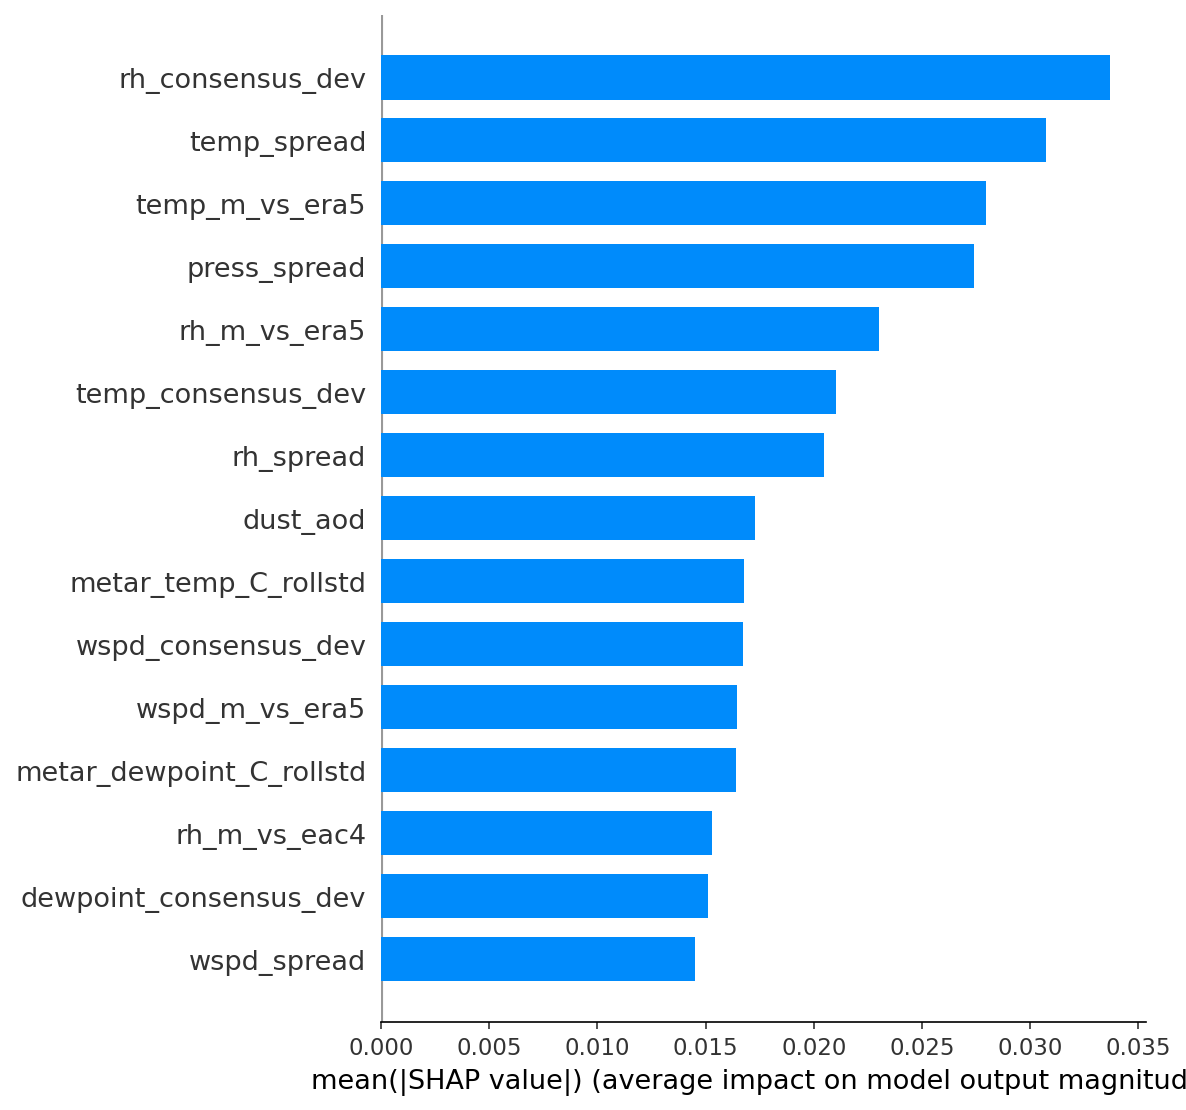

Beeswarm:


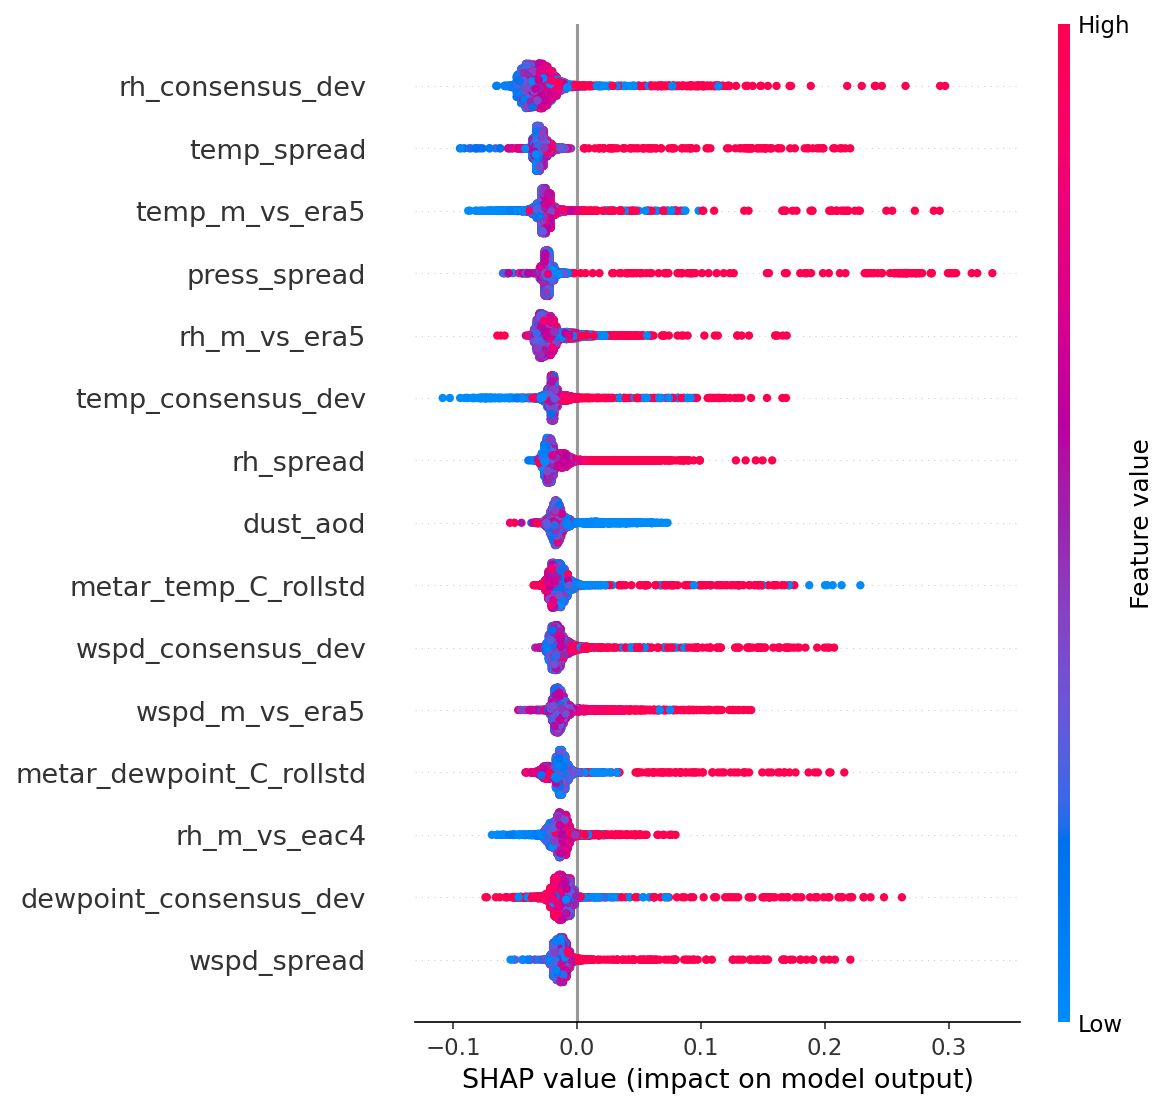

In [ ]:
from IPython.display import Image, display
OUT = "/content/drive/MyDrive/Aerosentinental/outputs"
print("Global bar:"); display(Image(f"{OUT}/shap_global_bar.png"))
print("Beeswarm:");   display(Image(f"{OUT}/shap_beeswarm.png"))

**Here's the McNemar cell. It statistically tests your three-tier comparison so you can claim significance, not just raw metric gaps.**

In [ ]:
import pandas as pd, numpy as np
from statsmodels.stats.contingency_tables import mcnemar
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

# --- load the three models' predictions ---
sup = pd.read_parquet(f"{PROC}/scored_supervised.parquet")   # supervised RF
uns = pd.read_parquet(f"{PROC}/scored_test_v2.parquet")      # unsupervised (improved IForest)

# align supervised & unsupervised on the same test rows
m = sup.merge(uns, on=["time","airport"], suffixes=("_sup","_uns"))
y   = m["attack_label_sup"].values
p_s = m["pred_sup"].values
p_u = m["pred_uns"].values

# rebuild threshold baseline on the identical test portion
fa = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
z = ((fa[raw]-fa[raw].mean())/fa[raw].std()).abs().max(axis=1)
cut = int(len(fa)*0.6)
# align baseline rows to the merged test set order
base_full = pd.DataFrame({"time": fa["time"], "airport": fa["airport"],
                          "base_pred": (z > 3).astype(int)}).iloc[cut:]
mb = m.merge(base_full, on=["time","airport"], how="left")
p_b = mb["base_pred"].fillna(0).astype(int).values

def run_mcnemar(name, y, a, b):
    a_ok, b_ok = (a==y), (b==y)
    n00 = int(np.sum(a_ok & b_ok))       # both right
    n01 = int(np.sum(a_ok & ~b_ok))      # A right, B wrong
    n10 = int(np.sum(~a_ok & b_ok))      # A wrong, B right
    n11 = int(np.sum(~a_ok & ~b_ok))     # both wrong
    table = [[n00, n01],[n10, n11]]
    # exact binomial if discordant pairs are few, else chi-square w/ correction
    exact = (n01 + n10) < 25
    res = mcnemar(table, exact=exact, correction=True)
    stat_name = "exact p" if exact else "chi2"
    stat_val  = "" if exact else f"chi2={res.statistic:.3f}, "
    print(f"{name}")
    print(f"   both right={n00} | A-only right={n01} | B-only right={n10} | both wrong={n11}")
    print(f"   {stat_val}p={res.pvalue:.4g}  ->  "
          f"{'SIGNIFICANT (p<0.05)' if res.pvalue<0.05 else 'not significant'}\n")

print("=== McNemar's tests (paired, same test rows) ===")
print(f"(A listed first in each pair)\n")
run_mcnemar("Supervised RF   vs   Unsupervised IForest", y, p_s, p_u)
run_mcnemar("Supervised RF   vs   Threshold baseline",   y, p_s, p_b)
run_mcnemar("Unsupervised    vs   Threshold baseline",   y, p_u, p_b)

=== McNemar's tests (paired, same test rows) ===
(A listed first in each pair)

Supervised RF   vs   Unsupervised IForest
   both right=4819 | A-only right=253 | B-only right=20 | both wrong=168
   chi2=197.158, p=8.713e-45  ->  SIGNIFICANT (p<0.05)

Supervised RF   vs   Threshold baseline
   both right=4940 | A-only right=132 | B-only right=12 | both wrong=176
   chi2=98.340, p=3.523e-23  ->  SIGNIFICANT (p<0.05)

Unsupervised    vs   Threshold baseline
   both right=4772 | A-only right=67 | B-only right=180 | both wrong=241
   chi2=50.785, p=1.03e-12  ->  SIGNIFICANT (p<0.05)



In [ ]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)

# rebuild the same feature set used everywhere
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]

def train_test(train_ap, test_ap):
    tr = feat[feat["airport"]==train_ap]
    te = feat[feat["airport"]==test_ap]
    clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
    clf.fit(tr[cols].values, tr["attack_label"].values)
    proba = clf.predict_proba(te[cols].values)[:,1]
    pred  = clf.predict(te[cols].values)
    yte   = te["attack_label"].values
    auc = roc_auc_score(yte, proba)
    p,r,f,_ = precision_recall_fscore_support(yte, pred, average="binary", zero_division=0)
    # per-attack recall
    te = te.copy(); te["pred"]=pred
    rec = {t: round(te.loc[te["attack_type"]==t,"pred"].mean(),2)
           for t in ["spike","stuck","drift","noise","offset"]
           if (te["attack_type"]==t).sum()}
    # dust false-positive
    clean = te["attack_label"]==0
    fa_te = fa[fa["airport"]==test_ap]
    dust = clean & (fa_te["eac4_dust_aod"].values > fa["eac4_dust_aod"].quantile(0.95))
    dust_fp = round(te.loc[dust,"pred"].mean()*100,1) if dust.sum() else float("nan")
    return auc,p,r,f,rec,dust_fp,int(dust.sum())

print("=== CROSS-AIRPORT TRANSFER (train on one, test on the other) ===\n")
for tr_ap, te_ap in [("OMAA","OMDB"), ("OMDB","OMAA")]:
    auc,p,r,f,rec,dfp,dn = train_test(tr_ap, te_ap)
    print(f"Train {tr_ap} -> Test {te_ap}")
    print(f"   AUC={auc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")
    print(f"   per-attack recall: {rec}")
    print(f"   dust false-positive: {dfp}% (n={dn})\n")

# --- reference: within-airport (same-airport 60/40 time split) for comparison ---
print("=== REFERENCE: within-airport (time split) ===\n")
for ap in ["OMAA","OMDB"]:
    d = feat[feat["airport"]==ap].sort_values("time")
    cut = int(len(d)*0.6)
    clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
    clf.fit(d[cols].values[:cut], d["attack_label"].values[:cut])
    pr = clf.predict_proba(d[cols].values[cut:])[:,1]
    pd_= clf.predict(d[cols].values[cut:])
    yt = d["attack_label"].values[cut:]
    p,r,f,_ = precision_recall_fscore_support(yt, pd_, average="binary", zero_division=0)
    print(f"{ap} within-airport: AUC={roc_auc_score(yt,pr):.3f}  P={p:.3f}  R={r:.3f}  F1={f:.3f}")

=== CROSS-AIRPORT TRANSFER (train on one, test on the other) ===

Train OMAA -> Test OMDB
   AUC=0.887  Precision=0.955  Recall=0.532  F1=0.684
   per-attack recall: {'spike': np.float64(0.95), 'stuck': np.float64(0.12), 'drift': np.float64(0.58), 'noise': np.float64(0.49), 'offset': np.float64(0.52)}
   dust false-positive: 0.4% (n=277)

Train OMDB -> Test OMAA
   AUC=0.905  Precision=0.970  Recall=0.482  F1=0.644
   per-attack recall: {'spike': np.float64(0.78), 'stuck': np.float64(0.2), 'drift': np.float64(0.33), 'noise': np.float64(0.38), 'offset': np.float64(0.53)}
   dust false-positive: 0.6% (n=346)

=== REFERENCE: within-airport (time split) ===

OMAA within-airport: AUC=0.919  P=0.980  R=0.402  F1=0.570
OMDB within-airport: AUC=0.873  P=0.958  R=0.436  F1=0.599



fig1_roc_tiers:


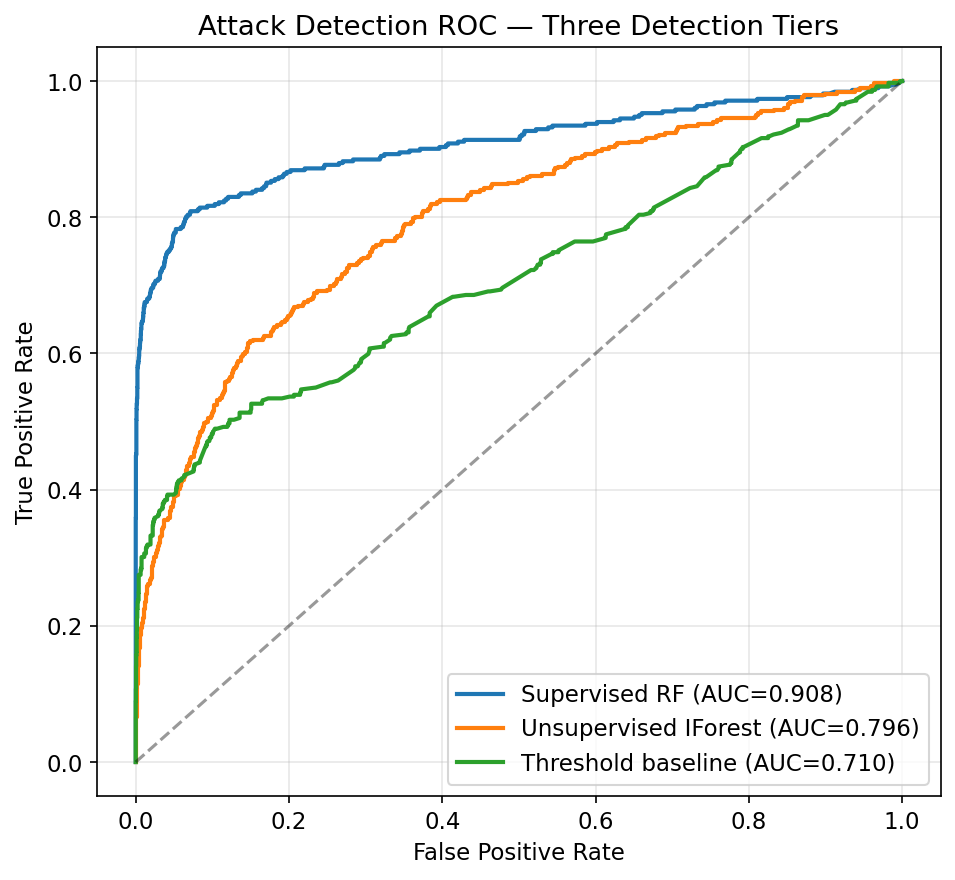


fig2_recall_by_type:


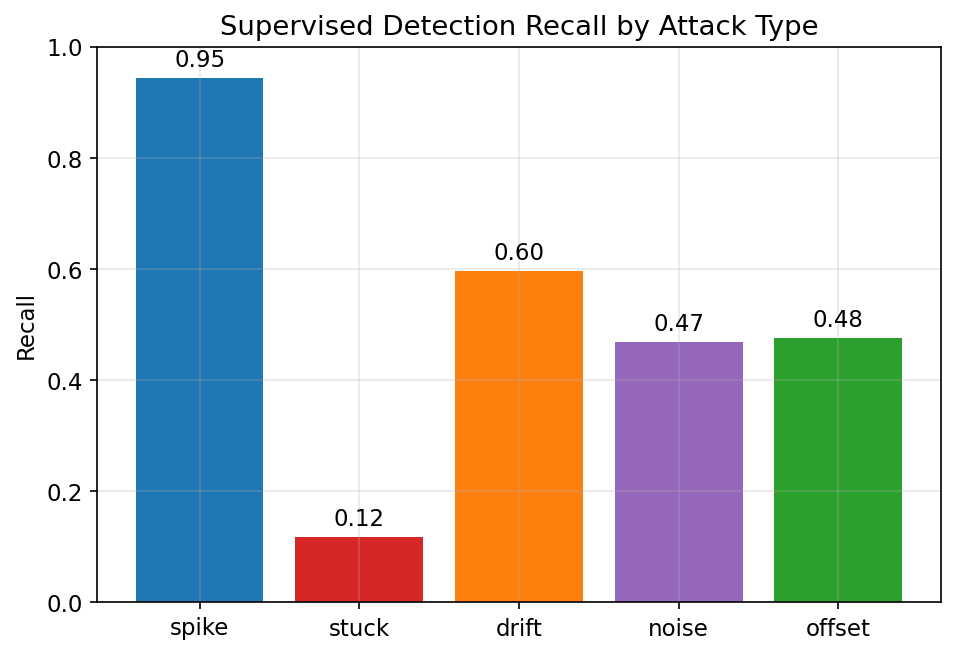


fig3_transfer:


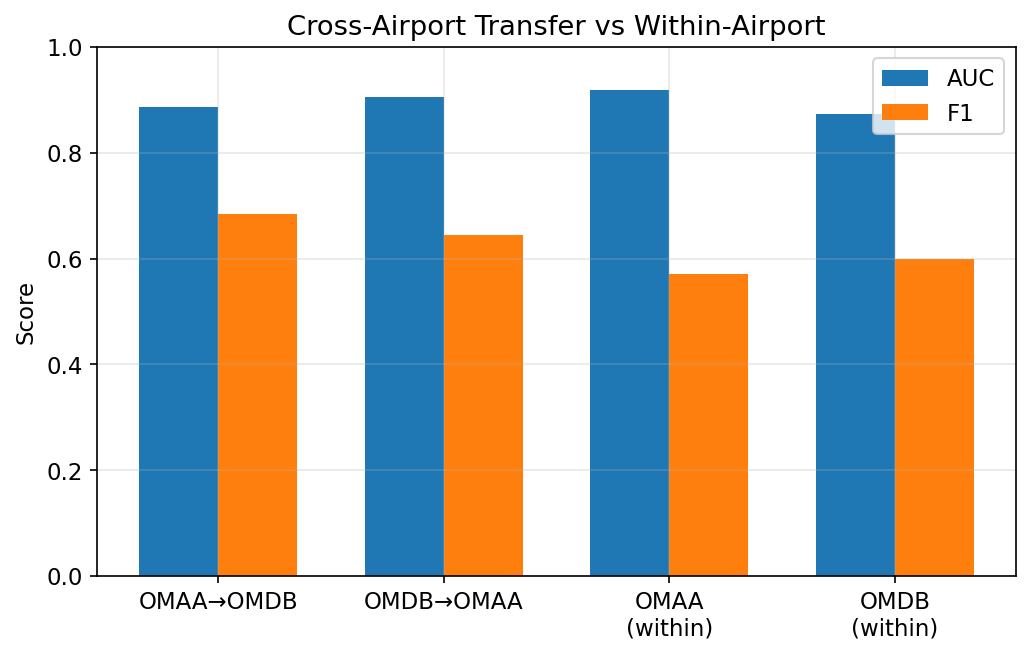


fig4_dust_fp:


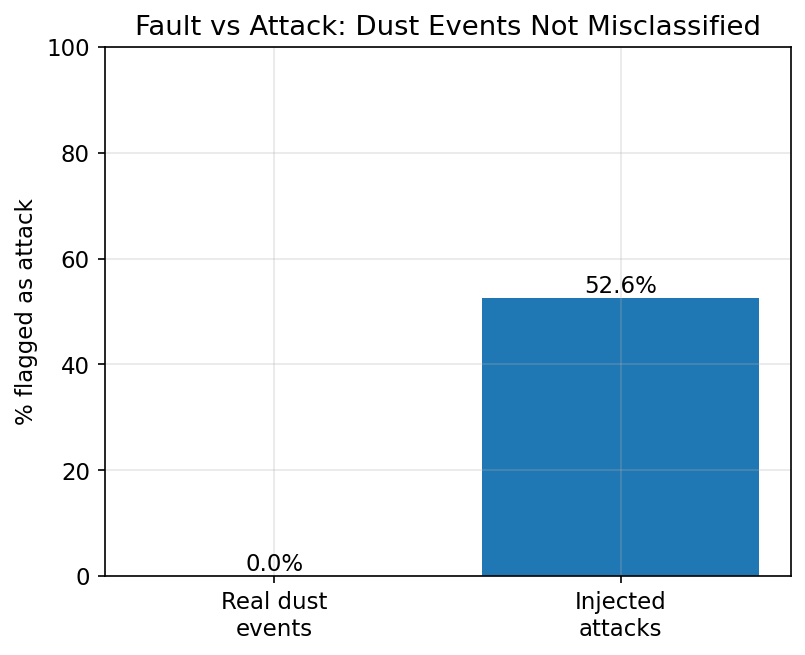


fig5_consistency_timeseries:


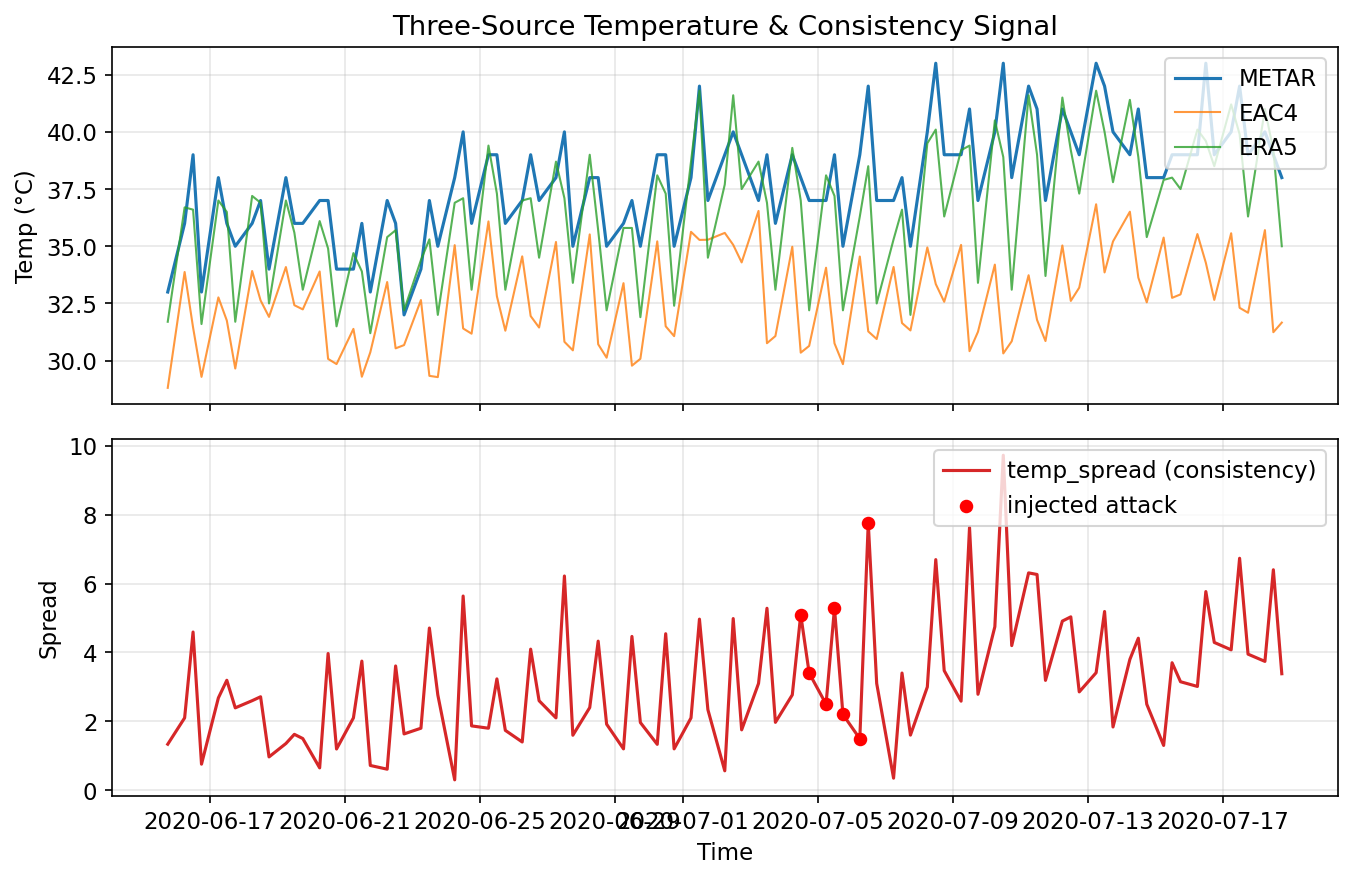


shap_global_bar:


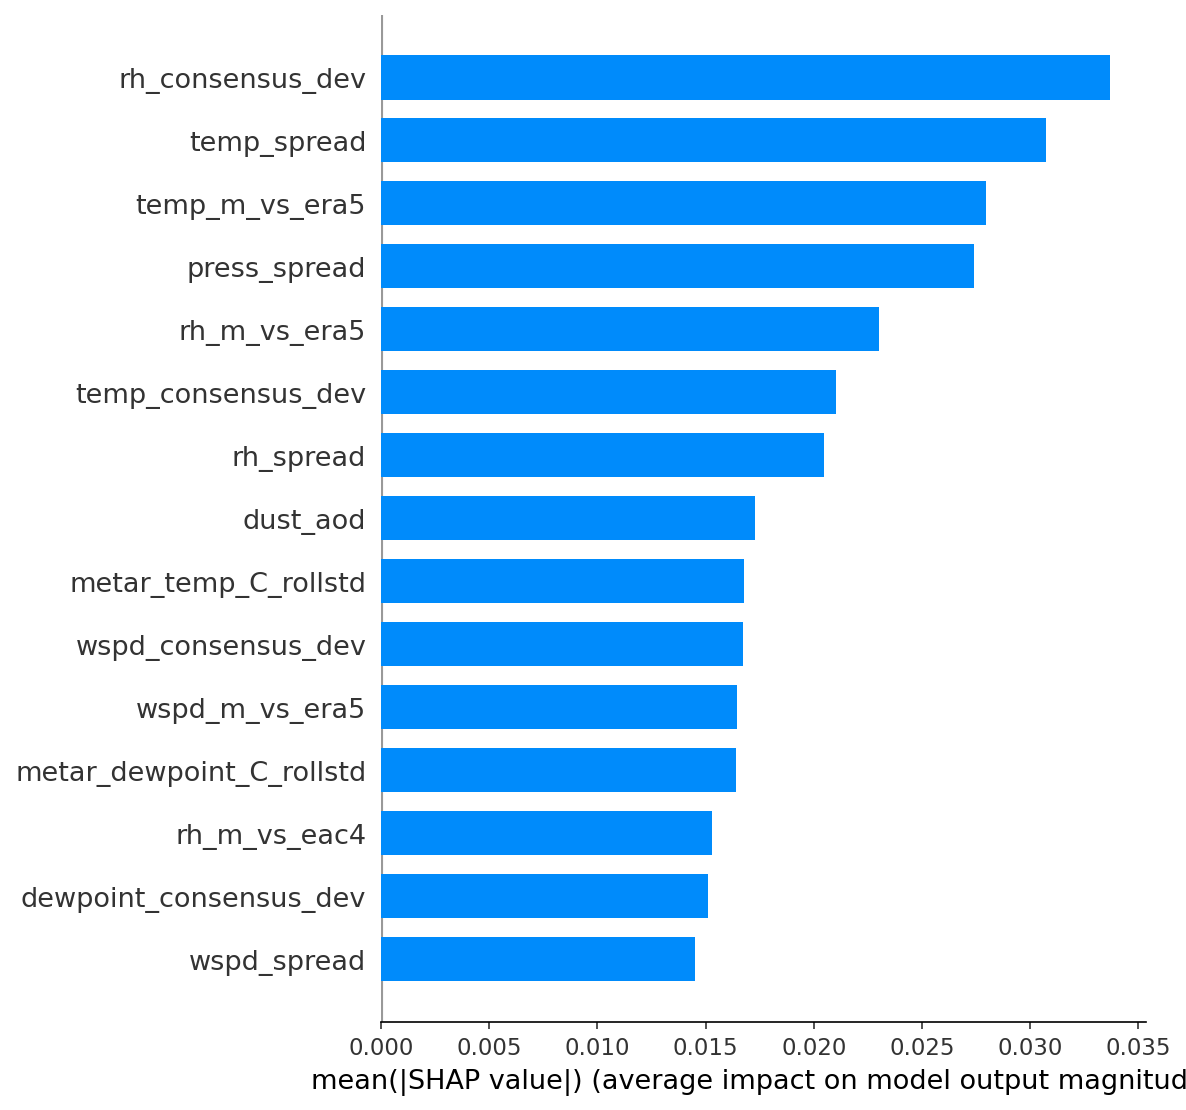


shap_beeswarm:


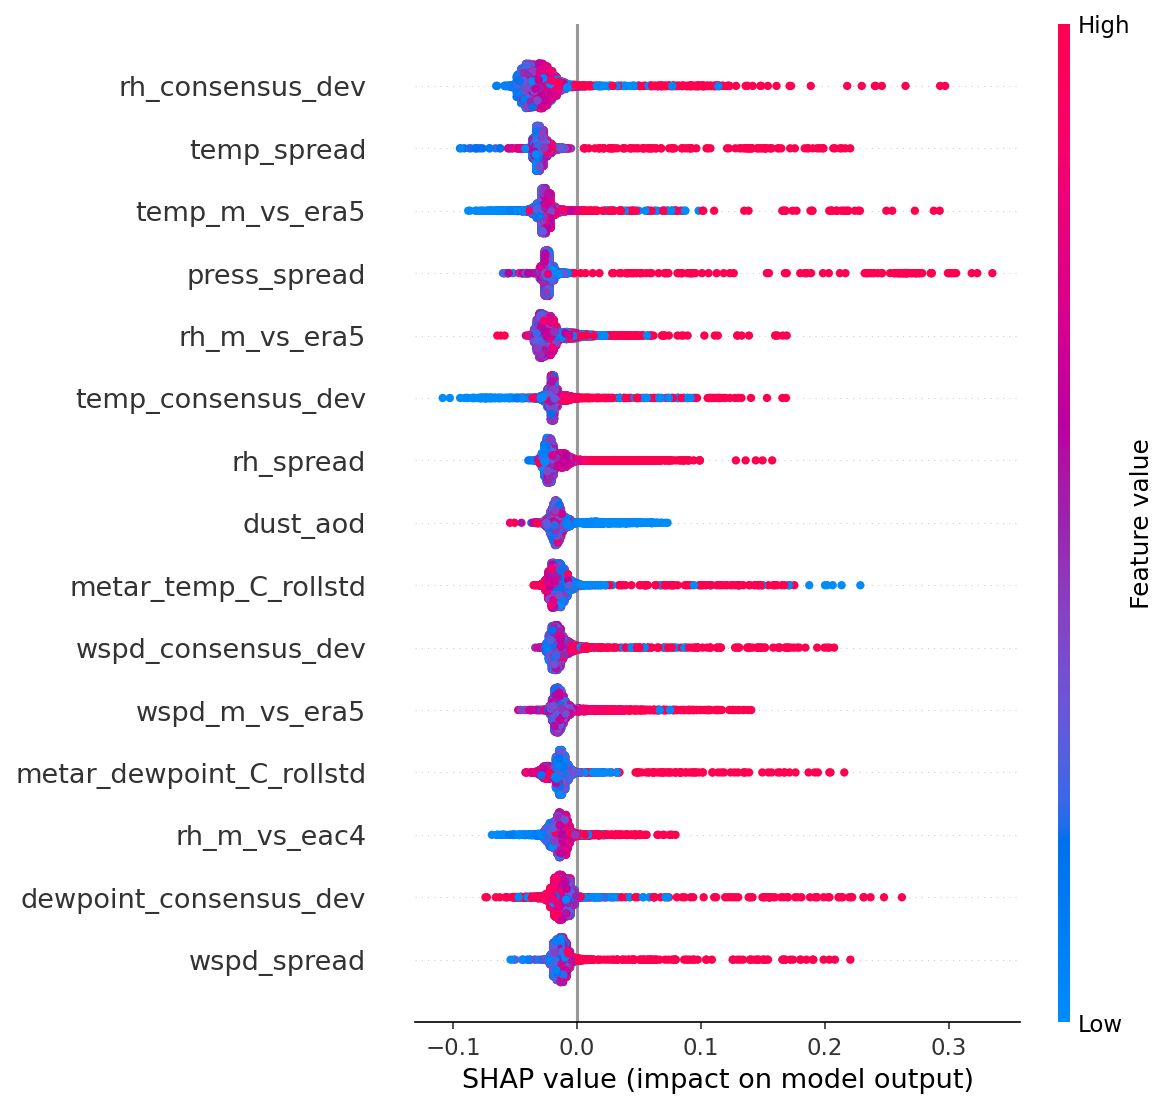


All figures saved to /content/drive/MyDrive/Aerosentinental/outputs


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc as sk_auc, precision_recall_fscore_support
from pyod.models.iforest import IForest
PROC = "/content/drive/MyDrive/Aerosentinental/processed"
OUT  = "/content/drive/MyDrive/Aerosentinental/outputs"; os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({"figure.dpi":150, "font.size":11, "axes.grid":True, "grid.alpha":0.3})

# rebuild feature matrix
feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
cons = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]
y = feat["attack_label"].values; cut = int(len(feat)*0.6)
yte = y[cut:]

# --- recompute the three tiers' scores on the test set ---
# supervised RF
clf = joblib.load(f"{PROC}/rf_detector.joblib")
rf_score = clf.predict_proba(feat[cons].values[cut:])[:,1]
rf_pred  = clf.predict(feat[cons].values[cut:])
# unsupervised IForest
if_model = IForest(contamination=0.05, random_state=42).fit(feat[cons].values[:cut])
if_score = if_model.decision_function(feat[cons].values[cut:])
# threshold baseline
z = ((fa[raw]-fa[raw].mean())/fa[raw].std()).abs().max(axis=1).values
base_score = z[cut:]

# ================= FIG 1: ROC curves, all three tiers =================
plt.figure(figsize=(6.5,6))
for name, score, color in [("Supervised RF", rf_score, "C0"),
                           ("Unsupervised IForest", if_score, "C1"),
                           ("Threshold baseline", base_score, "C2")]:
    fpr,tpr,_ = roc_curve(yte, score)
    plt.plot(fpr,tpr,color=color,lw=2,label=f"{name} (AUC={sk_auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--",alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Attack Detection ROC — Three Detection Tiers"); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{OUT}/fig1_roc_tiers.png", bbox_inches="tight"); plt.close()

# ================= FIG 2: per-attack recall (supervised) =================
test = feat.iloc[cut:].copy(); test["pred"]=rf_pred
types = ["spike","stuck","drift","noise","offset"]
recs = [test.loc[test["attack_type"]==t,"pred"].mean() for t in types]
plt.figure(figsize=(6.5,4.5))
bars = plt.bar(types, recs, color=["C0","C3","C1","C4","C2"])
for b,r in zip(bars,recs): plt.text(b.get_x()+b.get_width()/2, r+0.02, f"{r:.2f}", ha="center")
plt.ylim(0,1); plt.ylabel("Recall"); plt.title("Supervised Detection Recall by Attack Type")
plt.tight_layout(); plt.savefig(f"{OUT}/fig2_recall_by_type.png", bbox_inches="tight"); plt.close()

# ================= FIG 3: cross-airport transfer vs within =================
labels = ["OMAA→OMDB","OMDB→OMAA","OMAA\n(within)","OMDB\n(within)"]
aucs   = [0.887, 0.905, 0.919, 0.873]
f1s    = [0.684, 0.644, 0.570, 0.599]
x = np.arange(len(labels)); w=0.35
plt.figure(figsize=(7,4.5))
plt.bar(x-w/2, aucs, w, label="AUC", color="C0")
plt.bar(x+w/2, f1s,  w, label="F1",  color="C1")
plt.xticks(x, labels); plt.ylim(0,1); plt.ylabel("Score")
plt.title("Cross-Airport Transfer vs Within-Airport"); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/fig3_transfer.png", bbox_inches="tight"); plt.close()

# ================= FIG 4: dust false-positive check =================
clean = test["attack_label"]==0
fa_te = fa.iloc[cut:]
dust_thr = fa["eac4_dust_aod"].quantile(0.95)
real_dust = clean & (fa_te["eac4_dust_aod"].values > dust_thr)
cats = ["Real dust\nevents","Injected\nattacks"]
fp_dust = test.loc[real_dust,"pred"].mean()*100
tp_atk  = test.loc[test["attack_label"]==1,"pred"].mean()*100
plt.figure(figsize=(5.5,4.5))
bars=plt.bar(cats, [fp_dust, tp_atk], color=["C2","C0"])
for b,v in zip(bars,[fp_dust,tp_atk]): plt.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha="center")
plt.ylabel("% flagged as attack"); plt.ylim(0,100)
plt.title("Fault vs Attack: Dust Events Not Misclassified")
plt.tight_layout(); plt.savefig(f"{OUT}/fig4_dust_fp.png", bbox_inches="tight"); plt.close()

# ================= FIG 5: consistency feature time series example =================
ex = fa[fa["airport"]=="OMDB"].iloc[500:600]
exf = feat[feat["airport"]=="OMDB"].iloc[500:600]
fig,ax=plt.subplots(2,1,figsize=(9,6),sharex=True)
ax[0].plot(ex["time"], ex["metar_temp_C"], label="METAR", lw=1.5)
ax[0].plot(ex["time"], ex["eac4_temp_C"], label="EAC4", lw=1, alpha=0.8)
ax[0].plot(ex["time"], ex["era5_temp_C"], label="ERA5", lw=1, alpha=0.8)
ax[0].set_ylabel("Temp (°C)"); ax[0].legend(loc="upper right"); ax[0].set_title("Three-Source Temperature & Consistency Signal")
ax[1].plot(exf["time"], exf["temp_spread"], color="C3", label="temp_spread (consistency)")
atk = exf["attack_label"]==1
ax[1].scatter(exf.loc[atk,"time"], exf.loc[atk,"temp_spread"], color="red", s=30, zorder=5, label="injected attack")
ax[1].set_ylabel("Spread"); ax[1].legend(loc="upper right"); ax[1].set_xlabel("Time")
plt.tight_layout(); plt.savefig(f"{OUT}/fig5_consistency_timeseries.png", bbox_inches="tight"); plt.close()

# ================= display all inline =================
from IPython.display import Image, display
for f in ["fig1_roc_tiers","fig2_recall_by_type","fig3_transfer","fig4_dust_fp",
          "fig5_consistency_timeseries","shap_global_bar","shap_beeswarm"]:
    p=f"{OUT}/{f}.png"
    if os.path.exists(p): print(f"\n{f}:"); display(Image(p))
print("\nAll figures saved to", OUT)

In [ ]:
!pip install -q gradio shap pyod

import gradio as gr
import pandas as pd, numpy as np, joblib, shap
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

# ---------- load data + model once ----------
feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
COLS = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]

clf = joblib.load(f"{PROC}/rf_detector.joblib")
explainer = shap.TreeExplainer(clf)
STD = {c: fa[c].std() for c in raw}   # for attack scaling

def circ_diff(a,b): return (a-b+180)%360-180

def rebuild_features(df):
    """recompute consistency+temporal features for a (possibly attacked) fused slice"""
    f = pd.DataFrame(index=df.index)
    pairs = {"temp":("metar_temp_C","eac4_temp_C","era5_temp_C"),
             "dewpoint":("metar_dewpoint_C","eac4_dewpoint_C","era5_dewpoint_C"),
             "rh":("metar_rel_humidity","eac4_rel_humidity","era5_rel_humidity"),
             "wspd":("metar_wind_speed","eac4_wind_speed","era5_wind_speed"),
             "press":("metar_pressure_hPa","eac4_mslp_hPa","era5_mslp_hPa")}
    for name,(m,e4,e5) in pairs.items():
        off4=(df[m]-df[e4]).median(); off5=(df[m]-df[e5]).median()
        f[f"{name}_m_vs_eac4"]=df[m]-(df[e4]+off4)
        f[f"{name}_m_vs_era5"]=df[m]-(df[e5]+off5)
        f[f"{name}_eac4_vs_era5"]=(df[e4]+off4)-(df[e5]+off5)
        f[f"{name}_consensus_dev"]=f[[f"{name}_m_vs_eac4",f"{name}_m_vs_era5"]].mean(axis=1)
        f[f"{name}_spread"]=f[[f"{name}_m_vs_eac4",f"{name}_m_vs_era5",f"{name}_eac4_vs_era5"]].abs().max(axis=1)
    low=df["metar_wind_speed"]<1.5
    f["wdir_m_vs_eac4"]=circ_diff(df["metar_wind_dir"],df["eac4_wind_dir"])
    f["wdir_m_vs_era5"]=circ_diff(df["metar_wind_dir"],df["era5_wind_dir"])
    f.loc[low,["wdir_m_vs_eac4","wdir_m_vs_era5"]]=0.0
    for c in raw:
        f[f"{c}_step"]=df[c].diff().abs().fillna(0)
        f[f"{c}_rollstd"]=df[c].rolling(4,min_periods=2).std().fillna(0)
    f["dust_aod"]=df["eac4_dust_aod"].values
    f["dust_high"]=(df["eac4_dust_aod"]>fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
    return f.fillna(0)

# ---------- TAB 1: scoring view ----------
def score_window(airport, start_idx, window):
    sub = fa[fa["airport"]==airport].reset_index(drop=True)
    s=int(start_idx); e=min(s+int(window), len(sub))
    sl=sub.iloc[s:e].copy()
    X=rebuild_features(sl)[COLS].values
    pred=clf.predict(X); proba=clf.predict_proba(X)[:,1]
    fig,ax=plt.subplots(2,1,figsize=(10,6),sharex=True)
    t=sl["time"]
    ax[0].plot(t,sl["metar_temp_C"],label="METAR",lw=1.5)
    ax[0].plot(t,sl["eac4_temp_C"],label="EAC4",lw=1,alpha=.8)
    ax[0].plot(t,sl["era5_temp_C"],label="ERA5",lw=1,alpha=.8)
    ax[0].set_ylabel("Temp (°C)"); ax[0].legend(loc="upper right")
    ax[0].set_title(f"{airport}: three-source temperature")
    ax[1].plot(t,proba,color="C3",label="attack probability")
    flag=pred==1
    ax[1].scatter(t[flag],proba[flag],color="red",s=40,zorder=5,label="FLAGGED")
    ax[1].axhline(0.5,ls="--",color="grey",alpha=.5)
    ax[1].set_ylabel("Trust score"); ax[1].set_ylim(0,1); ax[1].legend(loc="upper right")
    fig.autofmt_xdate(rotation=30); plt.tight_layout()
    n_flag=int(flag.sum())
    summary=f"Window: {t.iloc[0]} → {t.iloc[-1]}\nReadings: {len(sl)} | Flagged as suspect: {n_flag} ({100*n_flag/len(sl):.1f}%)"
    return fig, summary

# ---------- TAB 2: attack simulator ----------
def simulate(airport, start_idx, window, variable, atk_type, magnitude):
    sub = fa[fa["airport"]==airport].reset_index(drop=True)
    s=int(start_idx); e=min(s+int(window),len(sub))
    sl=sub.iloc[s:e].copy().reset_index(drop=True)
    clean_X=rebuild_features(sl)[COLS].values
    clean_pred=clf.predict(clean_X)
    # inject attack into chosen variable across the window
    atk=sl.copy(); col=variable; sd=STD[col]; L=len(atk)
    if atk_type=="spike":
        atk[col]+=np.sign(np.random.randn(L))*sd*magnitude
    elif atk_type=="drift":
        atk[col]+=np.linspace(0,sd*magnitude,L)
    elif atk_type=="offset":
        atk[col]+=sd*magnitude
    elif atk_type=="stuck":
        atk[col]=atk[col].iloc[0]
    elif atk_type=="noise":
        atk[col]+=np.random.normal(0,sd*magnitude,L)
    atk_X=rebuild_features(atk)[COLS].values
    atk_pred=clf.predict(atk_X); atk_proba=clf.predict_proba(atk_X)[:,1]
    caught=int(atk_pred.sum())
    fig,ax=plt.subplots(2,1,figsize=(10,6),sharex=True)
    t=atk["time"]
    ax[0].plot(t,sl[col],label=f"original {col}",lw=1.5,alpha=.6)
    ax[0].plot(t,atk[col],label=f"attacked {col}",lw=1.5,color="C3")
    ax[0].set_ylabel(col); ax[0].legend(loc="upper right")
    ax[0].set_title(f"{atk_type} attack on {col} (magnitude {magnitude}σ)")
    ax[1].plot(t,atk_proba,color="C3",label="attack probability")
    flag=atk_pred==1
    ax[1].scatter(t[flag],atk_proba[flag],color="red",s=40,zorder=5,label="DETECTED")
    ax[1].axhline(0.5,ls="--",color="grey",alpha=.5)
    ax[1].set_ylabel("Trust score"); ax[1].set_ylim(0,1); ax[1].legend(loc="upper right")
    fig.autofmt_xdate(rotation=30); plt.tight_layout()
    verdict=f"Injected {atk_type} on {col} ({magnitude}σ) across {L} readings.\nDETECTED: {caught}/{L} ({100*caught/L:.0f}%)"
    if caught/L>0.5: verdict+="\n✅ Attack caught."
    elif caught>0: verdict+="\n⚠️ Partially detected."
    else: verdict+="\n❌ Attack evaded detection (stealthy)."
    return fig, verdict

# ---------- build UI ----------
airports=["OMAA","OMDB"]; maxidx=len(fa[fa.airport=="OMAA"])-100
with gr.Blocks(title="AeroSentinel") as demo:
    gr.Markdown("# 🛡️ AeroSentinel — Airport Environmental Data Trust Layer\nDetecting corrupted & manipulated sensor data before it reaches airport AI.")
    with gr.Tab("Live Scoring"):
        with gr.Row():
            ap1=gr.Dropdown(airports,value="OMAA",label="Airport")
            si1=gr.Slider(0,maxidx,value=500,step=20,label="Start index")
            w1=gr.Slider(50,300,value=120,step=10,label="Window (readings)")
        btn1=gr.Button("Score window",variant="primary")
        out1=gr.Plot(); txt1=gr.Textbox(label="Summary")
        btn1.click(score_window,[ap1,si1,w1],[out1,txt1])
    with gr.Tab("Attack Simulator"):
        with gr.Row():
            ap2=gr.Dropdown(airports,value="OMDB",label="Airport")
            si2=gr.Slider(0,maxidx,value=500,step=20,label="Start index")
            w2=gr.Slider(20,120,value=60,step=10,label="Window")
        with gr.Row():
            var=gr.Dropdown(raw,value="metar_temp_C",label="Variable to attack")
            typ=gr.Dropdown(["spike","drift","offset","stuck","noise"],value="spike",label="Attack type")
            mag=gr.Slider(0.5,6,value=3,step=0.5,label="Magnitude (σ)")
        btn2=gr.Button("Inject & detect",variant="primary")
        out2=gr.Plot(); txt2=gr.Textbox(label="Detection result")
        btn2.click(simulate,[ap2,si2,w2,var,typ,mag],[out2,txt2])
    gr.Markdown("*Supervised RF detector | AUC 0.908 | features: cross-source consistency (METAR↔EAC4↔ERA5) + temporal + dust context*")

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9c77b28669c5953ef4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Cell A — Reproducibility: config block + pinned dependencies + fixed seeds**

In [ ]:
# ============================================================
# AeroSentinel — Configuration & Reproducibility
# ============================================================
!pip install -q numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 \
    pyod==2.0.5 shap==0.46.0 xarray==2025.1.2 netCDF4 h5netcdf \
    pyarrow gradio matplotlib joblib statsmodels

import os, random, numpy as np

# ---- reproducibility: single global seed ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ---- central config (change paths/params here only) ----
CONFIG = {
    "seed": SEED,
    "project_dir": "/content/drive/MyDrive/Aerosentinental",
    "airports": {
        "OMAA": {"lat": 24.433, "lon": 54.651},   # Abu Dhabi Intl
        "OMDB": {"lat": 25.253, "lon": 55.364},   # Dubai Intl
    },
    "date_start": "2020-01-01",
    "date_end":   "2025-12-31",
    "resample_freq_hours": 6,
    "gulf_bbox": {"north": 27, "south": 22, "west": 51, "east": 57},
    "attack_rate_target": 0.12,
    "attack_types": ["spike", "stuck", "drift", "noise", "offset"],
    "train_frac": 0.60,
    "rf_params": {"n_estimators": 300, "class_weight": "balanced",
                  "min_samples_leaf": 2, "random_state": SEED, "n_jobs": -1},
    "contamination": 0.05,
}
CONFIG["proc_dir"] = f"{CONFIG['project_dir']}/processed"
CONFIG["out_dir"]  = f"{CONFIG['project_dir']}/outputs"
os.makedirs(CONFIG["proc_dir"], exist_ok=True)
os.makedirs(CONFIG["out_dir"], exist_ok=True)

# write a requirements file to the project for the appendix / submission
REQS = """numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
pyod==2.0.5
shap==0.46.0
xarray==2025.1.2
netCDF4
h5netcdf
pyarrow
gradio
matplotlib
joblib
statsmodels
cdsapi
"""
with open(f"{CONFIG['project_dir']}/requirements.txt", "w") as f:
    f.write(REQS)

print("Config loaded. Seed:", SEED)
print("Processed dir:", CONFIG["proc_dir"])
print("requirements.txt written to project root.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 25.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 12.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Config loaded. Seed: 42
Proce

**Precision-Recall curve + operational threshold selection**

In [ ]:
import pandas as pd, numpy as np, joblib, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_recall_fscore_support
PROC, OUT = CONFIG["proc_dir"], CONFIG["out_dir"]

# rebuild features + test scores from the supervised model
feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]

cut = int(len(feat)*CONFIG["train_frac"])
clf = joblib.load(f"{PROC}/rf_detector.joblib")
proba = clf.predict_proba(feat[cols].values[cut:])[:,1]
yte = feat["attack_label"].values[cut:]

prec, rec, thr = precision_recall_curve(yte, proba)
ap = average_precision_score(yte, proba)

# --- PR curve figure ---
plt.figure(figsize=(6.5,5))
plt.plot(rec, prec, lw=2, color="C0", label=f"Supervised RF (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve (test set)"); plt.legend(loc="lower left")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{OUT}/fig6_precision_recall.png", dpi=150, bbox_inches="tight"); plt.close()

# --- operational threshold selection ---
print("=== Operating points (choose by operational tolerance) ===\n")
# Option 1: high-precision regime (few false alarms — operationally preferred for alerting)
for target_prec in [0.95, 0.90, 0.80]:
    ok = np.where(prec[:-1] >= target_prec)[0]
    if len(ok):
        i = ok[np.argmax(rec[:-1][ok])]      # highest recall meeting the precision floor
        t = thr[i]
        pred = (proba >= t).astype(int)
        p,r,f,_ = precision_recall_fscore_support(yte, pred, average="binary", zero_division=0)
        print(f"  Precision≥{target_prec:.2f}: threshold={t:.3f} -> P={p:.3f} R={r:.3f} F1={f:.3f}")

# Option 2: F1-optimal threshold (balanced)
f1s = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
bi = np.argmax(f1s); bt = thr[bi]
pred = (proba >= bt).astype(int)
p,r,f,_ = precision_recall_fscore_support(yte, pred, average="binary", zero_division=0)
print(f"\n  F1-optimal: threshold={bt:.3f} -> P={p:.3f} R={r:.3f} F1={f:.3f}")

print(f"\nAverage Precision (area under PR): {ap:.3f}")
print(f"Saved fig6_precision_recall.png")

=== Operating points (choose by operational tolerance) ===

  Precision≥0.95: threshold=0.445 -> P=0.953 R=0.579 F1=0.720
  Precision≥0.90: threshold=0.394 -> P=0.903 R=0.610 F1=0.728
  Precision≥0.80: threshold=0.288 -> P=0.801 R=0.675 F1=0.733

  F1-optimal: threshold=0.305 -> P=0.833 R=0.668 F1=0.741

Average Precision (area under PR): 0.775
Saved fig6_precision_recall.png


**Cell A — Split-sensitivity + multi-seed check (answers #2: "not dependent on one arbitrary split")**

In [ ]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

# rebuild the feature matrix used by the supervised model
feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]
X = feat[cols].values; y = feat["attack_label"].values

# --- (1) sensitivity to the split point (temporal) ---
print("=== Split-point sensitivity (temporal, seed=42) ===")
split_aucs = []
for frac in [0.50, 0.55, 0.60, 0.65, 0.70]:
    cut = int(len(feat)*frac)
    clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
    clf.fit(X[:cut], y[:cut])
    p = clf.predict_proba(X[cut:])[:,1]
    auc = roc_auc_score(y[cut:], p); ap = average_precision_score(y[cut:], p)
    split_aucs.append(auc)
    print(f"  train {int(frac*100)}% : AUROC={auc:.3f}  AP={ap:.3f}  (test n={len(y)-cut})")
print(f"  --> AUROC range across splits: {min(split_aucs):.3f}–{max(split_aucs):.3f}")

# --- (2) sensitivity to the random seed (fixed 60/40 split) ---
print("\n=== Seed sensitivity (60/40 split) ===")
cut = int(len(feat)*0.60)
seed_aucs = []
for sd in [0, 1, 7, 42, 123]:
    clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 min_samples_leaf=2, random_state=sd, n_jobs=-1)
    clf.fit(X[:cut], y[:cut])
    p = clf.predict_proba(X[cut:])[:,1]
    auc = roc_auc_score(y[cut:], p); seed_aucs.append(auc)
    print(f"  seed {sd:>3} : AUROC={auc:.3f}")
print(f"  --> AUROC mean={np.mean(seed_aucs):.3f}, sd={np.std(seed_aucs):.4f}, "
      f"range {min(seed_aucs):.3f}–{max(seed_aucs):.3f}")

=== Split-point sensitivity (temporal, seed=42) ===
  train 50% : AUROC=0.887  AP=0.738  (test n=6575)
  train 55% : AUROC=0.896  AP=0.758  (test n=5918)
  train 60% : AUROC=0.908  AP=0.775  (test n=5260)
  train 65% : AUROC=0.914  AP=0.792  (test n=4603)
  train 70% : AUROC=0.909  AP=0.781  (test n=3945)
  --> AUROC range across splits: 0.887–0.914

=== Seed sensitivity (60/40 split) ===
  seed   0 : AUROC=0.909
  seed   1 : AUROC=0.909
  seed   7 : AUROC=0.909
  seed  42 : AUROC=0.908
  seed 123 : AUROC=0.911
  --> AUROC mean=0.909, sd=0.0012, range 0.908–0.911


**Cell B — Bootstrap confidence intervals (answers #3: "confidence intervals for performance metrics")**

In [ ]:
import numpy as np, pandas as pd, joblib
from sklearn.metrics import roc_auc_score, average_precision_score
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

# use the trained model's test-set scores (60/40)
cut = int(len(feat)*0.60)
clf = joblib.load(f"{PROC}/rf_detector.joblib")
proba = clf.predict_proba(X[cut:])[:,1]
yte = y[cut:]

def bootstrap_ci(y_true, y_score, metric, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true); stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)                 # resample with replacement
        if len(np.unique(y_true[idx])) < 2:          # need both classes
            continue
        stats.append(metric(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return np.mean(stats), lo, hi

for name, m in [("AUROC", roc_auc_score), ("Average Precision", average_precision_score)]:
    mean, lo, hi = bootstrap_ci(yte, proba, m)
    point = m(yte, proba)
    print(f"{name}: {point:.3f}  (95% CI {lo:.3f}–{hi:.3f})")

# also CI on the supervised recall at the 95%-precision operating point (threshold 0.445)
from sklearn.metrics import precision_recall_fscore_support
def recall_at_thr(y_true, y_score, thr=0.445):
    pred = (y_score >= thr).astype(int)
    _, r, _, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
    return r
mean, lo, hi = bootstrap_ci(yte, proba, lambda yt, ys: recall_at_thr(yt, ys))
print(f"Recall @ 95%-precision threshold: {recall_at_thr(yte,proba):.3f}  (95% CI {lo:.3f}–{hi:.3f})")

AUROC: 0.908  (95% CI 0.885–0.927)
Average Precision: 0.775  (95% CI 0.736–0.811)
Recall @ 95%-precision threshold: 0.579  (95% CI 0.528–0.628)


In [ ]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

# rebuild feature matrix
feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]

def boot_auc(y, s, n=2000, seed=42):
    rng = np.random.default_rng(seed); out=[]
    for _ in range(n):
        idx = rng.integers(0,len(y),len(y))
        if len(np.unique(y[idx]))<2: continue
        out.append(roc_auc_score(y[idx], s[idx]))
    return np.percentile(out,[2.5,97.5])

def boot_recall(hit, n=2000, seed=42):
    # hit = boolean array (was this attacked row detected?)
    rng = np.random.default_rng(seed); out=[]
    for _ in range(n):
        idx = rng.integers(0,len(hit),len(hit))
        out.append(hit[idx].mean())
    return np.percentile(out,[2.5,97.5])

# ---- (1) cross-airport transfer AUC CIs ----
print("=== Cross-airport transfer AUROC (95% CI) ===")
for tr, te in [("OMAA","OMDB"),("OMDB","OMAA")]:
    trd = feat[feat.airport==tr]; ted = feat[feat.airport==te]
    clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
    clf.fit(trd[cols].values, trd["attack_label"].values)
    s = clf.predict_proba(ted[cols].values)[:,1]; yv = ted["attack_label"].values
    auc = roc_auc_score(yv, s); lo,hi = boot_auc(yv, s)
    print(f"  {tr}->{te}: AUROC={auc:.3f} (95% CI {lo:.3f}-{hi:.3f})")

# ---- (2) per-attack recall CIs (supervised, 60/40) ----
print("\n=== Per-attack recall (95% CI), supervised 60/40 ===")
cut = int(len(feat)*0.60)
clf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             min_samples_leaf=2, random_state=42, n_jobs=-1)
clf.fit(feat[cols].values[:cut], feat["attack_label"].values[:cut])
pred = clf.predict(feat[cols].values[cut:])
test = feat.iloc[cut:].copy(); test["pred"]=pred
for t in ["spike","drift","offset","noise","stuck"]:
    m = test["attack_type"]==t
    if m.sum()==0: continue
    hit = (test.loc[m,"pred"]==1).values.astype(float)
    r = hit.mean(); lo,hi = boot_recall(hit)
    flag = "" if m.sum()>=30 else "  [small n — CI wide]"
    print(f"  {t:7s}: recall={r:.2f} (95% CI {lo:.2f}-{hi:.2f})  n={m.sum()}{flag}")

=== Cross-airport transfer AUROC (95% CI) ===
  OMAA->OMDB: AUROC=0.887 (95% CI 0.866-0.907)
  OMDB->OMAA: AUROC=0.905 (95% CI 0.887-0.922)

=== Per-attack recall (95% CI), supervised 60/40 ===
  spike  : recall=0.95 (95% CI 0.89-0.99)  n=91
  drift  : recall=0.60 (95% CI 0.47-0.73)  n=62
  offset : recall=0.48 (95% CI 0.35-0.60)  n=63
  noise  : recall=0.47 (95% CI 0.36-0.58)  n=81
  stuck  : recall=0.12 (95% CI 0.06-0.19)  n=85


In [ ]:
import pandas as pd, numpy as np
PROC = "/content/drive/MyDrive/Aerosentinental/processed"
fa = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)

cut = int(len(fa)*0.60)
# find contiguous attack runs and check whether any straddle the global cut
lab = fa["attack_label"].values
runs = []
i = 0
while i < len(lab):
    if lab[i] == 1:
        j = i
        while j < len(lab) and lab[j] == 1:
            j += 1
        runs.append((i, j-1))   # inclusive window
        i = j
    else:
        i += 1

straddling = [(a,b) for (a,b) in runs if a < cut <= b]
print(f"Total attacked rows: {int(lab.sum())}")
print(f"Contiguous attack runs: {len(runs)}")
print(f"Runs straddling the 60% boundary (row {cut}): {len(straddling)}")
print(f"Rows involved in straddling runs: {sum(b-a+1 for a,b in straddling)}")
if straddling:
    print("straddling runs:", straddling[:10])

Total attacked rows: 1012
Contiguous attack runs: 178
Runs straddling the 60% boundary (row 7890): 0
Rows involved in straddling runs: 0


In [ ]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
PROC = "/content/drive/MyDrive/Aerosentinental/processed"

feat = pd.read_parquet(f"{PROC}/features_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
fa   = pd.read_parquet(f"{PROC}/fused_attacked.parquet").sort_values(["airport","time"]).reset_index(drop=True)
raw = ["metar_temp_C","metar_dewpoint_C","metar_rel_humidity","metar_wind_speed","metar_pressure_hPa"]
for c in raw:
    feat[f"{c}_step"]    = fa.groupby("airport")[c].diff().abs().fillna(0).values
    feat[f"{c}_rollstd"] = fa.groupby("airport")[c].transform(lambda s: s.rolling(4,min_periods=2).std()).fillna(0).values
feat["dust_aod"]  = fa["eac4_dust_aod"].values
feat["dust_high"] = (fa["eac4_dust_aod"] > fa["eac4_dust_aod"].quantile(0.90)).astype(int).values
cols = [c for c in feat.columns if any(k in c for k in ["_vs_","consensus","spread","_step","_rollstd"])] + ["dust_aod","dust_high"]

# how the ORIGINAL transfer was done: train ALL of airport A, test ALL of airport B
print("=== Data overlap check ===")
for ap in ["OMAA","OMDB"]:
    d = feat[feat.airport==ap]
    print(f"  {ap}: {len(d)} rows, {int(d['attack_label'].sum())} attacked, "
          f"time {d['time'].min()} -> {d['time'].max()}")

# Are the two airports' attack windows correlated in time? (shared injection structure?)
oa = feat[feat.airport=="OMAA"].reset_index(drop=True)["attack_label"].values
ob = feat[feat.airport=="OMDB"].reset_index(drop=True)["attack_label"].values
n = min(len(oa), len(ob))
overlap = np.mean(oa[:n] == ob[:n])
both_attacked = np.mean((oa[:n]==1) & (ob[:n]==1))
print(f"\nAttack-label agreement between airports at same timestep: {overlap:.3f}")
print(f"Fraction of timesteps attacked in BOTH airports simultaneously: {both_attacked:.4f}")

# Sanity: does the transfer model, trained on A, test on B WITHOUT any time-holdout?
# report transfer AUC (full-B test) vs a time-honest transfer (train A-full, test only B's last 40%)
def rf(): return RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                        min_samples_leaf=2, random_state=42, n_jobs=-1)
for tr, te in [("OMAA","OMDB"),("OMDB","OMAA")]:
    trd = feat[feat.airport==tr]; ted = feat[feat.airport==te].reset_index(drop=True)
    m = rf().fit(trd[cols].values, trd["attack_label"].values)
    # full-B (original method)
    auc_full = roc_auc_score(ted["attack_label"].values, m.predict_proba(ted[cols].values)[:,1])
    # time-honest: only test on B's later 40%
    cut = int(len(ted)*0.60)
    yb = ted["attack_label"].values[cut:]
    auc_late = roc_auc_score(yb, m.predict_proba(ted[cols].values[cut:])[:,1])
    print(f"\n{tr}->{te}: full-B AUC={auc_full:.3f} | B-late-40% AUC={auc_late:.3f}")

=== Data overlap check ===
  OMAA: 6575 rows, 529 attacked, time 2020-01-01 06:00:00 -> 2025-12-31 18:00:00
  OMDB: 6575 rows, 483 attacked, time 2020-01-01 06:00:00 -> 2025-12-31 18:00:00

Attack-label agreement between airports at same timestep: 0.854
Fraction of timesteps attacked in BOTH airports simultaneously: 0.0041

OMAA->OMDB: full-B AUC=0.887 | B-late-40% AUC=0.880

OMDB->OMAA: full-B AUC=0.905 | B-late-40% AUC=0.904


In [ ]:
# %% [markdown]
# # AeroSentinel — Revision Pipeline (answers Reviews 1, 2, 3)
# Run these blocks **in order**, after cells 1–13 of the original notebook (they only need
# `processed/fused_6h.parquet`). They REPLACE original cells 14–45.
#
# Why: in the original notebook each analysis cell rebuilt its own features, used its own split and its own model
# (ablation = IForest, transfer/SHAP = first RF, PR threshold = picked on the TEST set). Reviewer 1 (#3, #5) caught this.
# Here there is ONE config, ONE split, ONE feature builder and ONE evaluation function, and every number in the
# revised paper comes from the `RESULTS` dictionary saved at the end.

# %% [markdown]
# ## BLOCK 0 — Single configuration (R1-#5, R3-#4 reproducibility)

# %%
import os, json, time, random, warnings, platform
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

CFG = {
    "seed": 42,
    "project_dir": "/content/drive/MyDrive/Aerosentinental",
    "airports": ["OMAA", "OMDB"],
    "train_frac": 0.60,                 # chronological cut on the CALENDAR (same date for both airports)
    "n_cv_folds": 4,                    # expanding-window temporal CV inside the training period
    "cv_embargo_steps": 12,             # gap (>max window length) between CV-train and CV-validation
    "attack_types": ["spike", "drift", "offset", "stuck", "noise"],
    "attack_rate": 0.08,                # target fraction of attacked rows per airport
    "win_len": (3, 8),                  # attack window length in timesteps
    "k_range": {"spike": (2.0, 6.0), "drift": (0.5, 4.0), "offset": (0.5, 3.0),
                "noise": (0.5, 3.0), "stuck": (0.0, 0.0)},   # magnitude k (x training-period sigma)
    "roll_win": 4,                      # rolling std window (temporal features)
    "persist_win": 8,                   # window for new stuck-sensor features
    "op_rule": ("precision", 0.95),     # operating point, chosen on OUT-OF-FOLD CV scores (never on test)
    "tuning_budget": 20,                # SAME number of hyper-parameter trials for every detector (R3-#3)
    "loao_budget": 8,                   # trials per model in leave-one-attack-out re-tuning
    "n_boot": 1000,
    "block_len": 28,                    # moving-block bootstrap length (~9 days at 3 obs/day)
    "robust_seeds": [0, 1, 7, 42, 123], # vary BOTH attack-injection seed and model seed
}
PROC = f"{CFG['project_dir']}/processed"
OUT = f"{CFG['project_dir']}/outputs_revision"
os.makedirs(OUT, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); os.environ["PYTHONHASHSEED"] = str(s)
set_seed(CFG["seed"])

TARGET_COLS = ["metar_temp_C", "metar_dewpoint_C", "metar_rel_humidity",
               "metar_wind_speed", "metar_pressure_hPa"]
PAIRS = {  # short name: (METAR, CAMS-EAC4, ERA5)
    "temp":     ("metar_temp_C", "eac4_temp_C", "era5_temp_C"),
    "dewpoint": ("metar_dewpoint_C", "eac4_dewpoint_C", "era5_dewpoint_C"),
    "rh":       ("metar_rel_humidity", "eac4_rel_humidity", "era5_rel_humidity"),
    "wspd":     ("metar_wind_speed", "eac4_wind_speed", "era5_wind_speed"),
    "press":    ("metar_pressure_hPa", "eac4_mslp_hPa", "era5_mslp_hPa"),
}
NAME_OF = {m: n for n, (m, _, _) in PAIRS.items()}
RESULTS = {"config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in CFG.items()}}
print("Config ready. Outputs ->", OUT)

# %% [markdown]
# ## BLOCK 1 — Load data + TRUE chronological split
# BUG FIXED: the original code sorted by `["airport","time"]` and cut at row 60%. That put ALL of OMAA
# (2020–2025) + the first ~20% of OMDB in training and tested only on OMDB 2021–2025, i.e. training contained data
# *later* than the test period. The paper's "chronological 60/40 split" was therefore not what the code did.

# %%
clean = pd.read_parquet(f"{PROC}/fused_6h.parquet")
clean["time"] = pd.to_datetime(clean["time"])
clean = clean.sort_values(["airport", "time"]).reset_index(drop=True)

utimes = np.sort(clean["time"].unique())
CUT = pd.Timestamp(utimes[int(len(utimes) * CFG["train_frac"])])
print("Chronological cut:", CUT, "| train: time < cut, test: time >= cut (both airports)")
print(clean.groupby("airport")["time"].agg(["min", "max", "count"]))

hours = clean["time"].dt.hour.value_counts().sort_index().to_dict()
print("Synoptic hours actually present:", hours)
print("  -> if 00 UTC is missing, the paper must NOT say '00, 06, 12, 18 UTC'.")
RESULTS["split"] = {"cut_time": str(CUT), "hours_present": {int(k): int(v) for k, v in hours.items()},
                    "n_train": int((clean.time < CUT).sum()), "n_test": int((clean.time >= CUT).sum())}

# %% [markdown]
# ## BLOCK 2 — Attack injection v2 (R1-#1, R2 stuck blind spot, R3-#1/#2)
# Fixes vs original: magnitudes k are actually sampled per window (paper claimed k∈[0.5,6] but code used fixed
# 2.5σ drift / 1.5σ noise); first row of drift and stuck windows is now really perturbed (before, it was labelled
# "attack" but unchanged = label noise, which partly explains stuck recall 0.12); stuck freezes at the value
# *before* the window; windows never overlap and never straddle the split; σ comes from the training period only;
# physical clipping (RH 0–100, wind ≥ 0) so attacks are not trivially "impossible values".
# `inject_unseen` creates NEW attack families used ONLY at test time (never trained or tuned on).

# %%
def _train_offsets(df, cut):
    """Median METAR-minus-reanalysis offsets per airport, TRAINING PERIOD ONLY."""
    off = {}
    tr = df["time"] < cut
    for name, (m, e4, e5) in PAIRS.items():
        for ap in df["airport"].unique():
            a = (df["airport"] == ap) & tr
            off[(name, ap)] = (float((df.loc[a, m] - df.loc[a, e4]).median()),
                               float((df.loc[a, m] - df.loc[a, e5]).median()))
    return off

def _clip_physical(df):
    df["metar_rel_humidity"] = df["metar_rel_humidity"].clip(0, 100)
    df["metar_wind_speed"] = df["metar_wind_speed"].clip(lower=0)
    return df

def _new_label_cols(df):
    df["attack_label"] = 0; df["attack_type"] = "clean"; df["attack_var"] = ""
    df["attack_k"] = 0.0; df["attack_delta_sd"] = 0.0; df["window_id"] = -1
    return df

def _sample_windows(df, rng, cut, rate, win_len, only_test):
    """Yield (airport, row_index_array) for non-overlapping windows that never straddle the cut."""
    for ap, g in df.groupby("airport"):
        idx = g.index.to_numpy(); t = g["time"].to_numpy(); n = len(idx)
        busy = np.zeros(n, bool); cutn = np.datetime64(cut)
        pool = (t >= cutn).sum() if only_test else n
        target, done, tries = int(rate * pool), 0, 0
        while done < target and tries < 200000:
            tries += 1
            L = int(rng.integers(win_len[0], win_len[1] + 1))
            s = int(rng.integers(1, n - L))
            if busy[max(0, s - 2): s + L + 2].any():
                continue
            in_tr = t[s] < cutn
            if in_tr != (t[s + L - 1] < cutn) or (only_test and in_tr):
                continue
            busy[s: s + L] = True; done += L
            yield ap, idx[s: s + L]

def inject_attacks(clean_df, seed, cut=None, types=None, rate=None):
    cut = cut or CUT; types = types or CFG["attack_types"]; rate = rate or CFG["attack_rate"]
    rng = np.random.default_rng(seed)
    df = _new_label_cols(clean_df.copy())
    SD = {c: clean_df.loc[clean_df.time < cut, c].std() for c in TARGET_COLS}
    for wid, (ap, rows) in enumerate(_sample_windows(df, rng, cut, rate, CFG["win_len"], False)):
        kind = str(rng.choice(types)); col = str(rng.choice(TARGET_COLS)); sd = SD[col]
        lo, hi = CFG["k_range"][kind]; k = float(rng.uniform(lo, hi)) if hi > 0 else 0.0
        L = len(rows); sign = rng.choice([-1, 1]); before = df.loc[rows, col].copy()
        if kind == "spike":
            df.loc[rows, col] += rng.choice([-1, 1], size=L) * k * sd
        elif kind == "drift":
            df.loc[rows, col] += sign * np.linspace(k * sd / L, k * sd, L)
        elif kind == "offset":
            df.loc[rows, col] += sign * k * sd
        elif kind == "noise":
            df.loc[rows, col] += rng.normal(0, k * sd, L)
        elif kind == "stuck":
            df.loc[rows, col] = df.loc[rows[0] - 1, col]      # frozen at last value BEFORE the window
        df = _clip_physical(df)
        df.loc[rows, "attack_delta_sd"] = ((df.loc[rows, col] - before).abs() / sd).values
        df.loc[rows, ["attack_label", "attack_type", "attack_var", "attack_k", "window_id"]] = \
            [1, kind, col, k, wid]
    return df

UNSEEN_TYPES = ["replay", "mimic_era5", "coupled_T_Td", "coord_metar_era5", "coord_all3", "slow_drift"]

def inject_unseen(clean_df, kind, seed, cut=None, rate=None):
    """Test-period-only attacks from families NEVER seen in training/tuning (R2, R3-#2, R1-#1)."""
    cut = cut or CUT; rate = rate or CFG["attack_rate"]
    rng = np.random.default_rng(seed)
    df = _new_label_cols(clean_df.copy())
    SD = {c: clean_df.loc[clean_df.time < cut, c].std() for c in TARGET_COLS}
    off = _train_offsets(clean_df, cut)
    tr = clean_df.time < cut
    win = (24, 40) if kind == "slow_drift" else CFG["win_len"]
    for wid, (ap, rows) in enumerate(_sample_windows(df, rng, cut, rate, win, True)):
        col = str(rng.choice(TARGET_COLS)); name = NAME_OF[col]; m, e4, e5 = PAIRS[name]
        sd = SD[col]; sign = rng.choice([-1, 1]); L = len(rows); before = df.loc[rows, col].copy()
        if kind == "replay":            # plausible values replayed from ~1 year earlier, same airport & slot
            src = df.loc[rows, "time"] - pd.Timedelta(days=364)
            hist = df[df.airport == ap].set_index("time")[col]
            vals = hist.reindex(src.values, method="nearest").values
            df.loc[rows, col] = vals; k = np.nan
        elif kind == "mimic_era5":      # ADAPTIVE: attacker copies calibrated ERA5 and adds a small bias
            resid_sd = float((clean_df.loc[tr, m] - clean_df.loc[tr, e5]).std())
            k = float(rng.uniform(0.5, 2.0))
            df.loc[rows, col] = df.loc[rows, e5] + off[(name, ap)][1] + sign * k * resid_sd
        elif kind == "coupled_T_Td":    # multi-variable, physically consistent: T and Td shifted together
            k = float(rng.uniform(0.5, 2.0)); d = sign * k * SD["metar_temp_C"]
            df.loc[rows, "metar_temp_C"] += d; df.loc[rows, "metar_dewpoint_C"] += d
            col = "metar_temp_C"
        elif kind == "coord_metar_era5":  # coordinated multi-source: METAR AND ERA5 feed both falsified
            k = float(rng.uniform(1.0, 3.0)); d = sign * k * sd
            df.loc[rows, col] += d; df.loc[rows, e5] += d
        elif kind == "coord_all3":      # all three sources falsified -> expected blind spot (report honestly)
            k = float(rng.uniform(1.0, 3.0)); d = sign * k * sd
            df.loc[rows, col] += d; df.loc[rows, e5] += d; df.loc[rows, e4] += d
        elif kind == "slow_drift":      # long-horizon stealthy drift (8–13 days)
            k = float(rng.uniform(1.0, 3.0))
            df.loc[rows, col] += sign * np.linspace(k * sd / L, k * sd, L)
        df = _clip_physical(df)
        df.loc[rows, "attack_delta_sd"] = ((df.loc[rows, col] - before).abs() / sd).values
        df.loc[rows, ["attack_label", "attack_type", "attack_var", "attack_k", "window_id"]] = \
            [1, kind, col, k, wid]
    return df

ATT = inject_attacks(clean, seed=CFG["seed"])
print("Attack prevalence:", round(ATT.attack_label.mean(), 4))
print(ATT.attack_type.value_counts())
print("Windows:", ATT.loc[ATT.window_id >= 0, "window_id"].nunique())
RESULTS["attacks"] = {"prevalence": float(ATT.attack_label.mean()),
                      "rows_by_type": ATT.attack_type.value_counts().to_dict(),
                      "n_windows": int(ATT.loc[ATT.window_id >= 0, "window_id"].nunique())}

# %% [markdown]
# ## BLOCK 3 — ONE feature builder, leakage-free (R1-#3/#5) + new stuck-sensor features (R2)
# Offsets, dust thresholds and all statistics are fitted on the training period only (paper already claims this;
# the original code used the full 2020–2025 series). New persistence features target the stuck blind spot:
# run-length of identical values, METAR/ERA5 rolling-variance ratio (→0 when METAR frozen but atmosphere moves),
# and rolling correlation of METAR vs ERA5 step changes.

# %%
def circ_diff(a, b):
    return (a - b + 180) % 360 - 180

def _run_length(s):
    same = s.diff().eq(0)
    return same.groupby((~same).cumsum()).cumsum().astype(float)

def build_features(df, cut, stats=None):
    """Return (F, stats). If stats is None they are fitted on rows with time < cut."""
    df = df.sort_values(["airport", "time"]).reset_index(drop=True)
    tr = df["time"] < cut
    fit = stats is None
    if fit:
        stats = {"off": _train_offsets(df, cut),
                 "dust_p90": float(df.loc[tr, "eac4_dust_aod"].quantile(0.90))}
    W, R = CFG["persist_win"], CFG["roll_win"]
    F = df[["time", "airport"]].copy()
    for c in ["attack_label", "attack_type", "attack_var", "attack_k", "attack_delta_sd", "window_id"]:
        if c in df:
            F[c] = df[c].values
    ap = df["airport"]
    for name, (m, e4, e5) in PAIRS.items():
        o4 = ap.map({a: stats["off"][(name, a)][0] for a in ap.unique()})
        o5 = ap.map({a: stats["off"][(name, a)][1] for a in ap.unique()})
        e4c, e5c = df[e4] + o4, df[e5] + o5
        F[f"{name}_m_vs_eac4"] = df[m] - e4c
        F[f"{name}_m_vs_era5"] = df[m] - e5c
        F[f"{name}_eac4_vs_era5"] = e4c - e5c
        F[f"{name}_consensus_dev"] = F[[f"{name}_m_vs_eac4", f"{name}_m_vs_era5"]].mean(axis=1)
        F[f"{name}_spread"] = F[[f"{name}_m_vs_eac4", f"{name}_m_vs_era5",
                                 f"{name}_eac4_vs_era5"]].abs().max(axis=1)
        # temporal (original names kept)
        F[f"{m}_step"] = df.groupby("airport")[m].diff().abs()
        F[f"{m}_rollstd"] = df.groupby("airport")[m].transform(lambda s: s.rolling(R, min_periods=2).std())
        # NEW persistence / stuck features
        F[f"{name}_runlen"] = df.groupby("airport")[m].transform(_run_length)
        msd = df.groupby("airport")[m].transform(lambda s: s.rolling(W, min_periods=3).std())
        esd = e5c.groupby(ap).transform(lambda s: s.rolling(W, min_periods=3).std())
        F[f"{name}_varratio"] = (msd / (esd + 1e-6)).clip(0, 10)
        dm, de = df.groupby("airport")[m].diff(), e5c.groupby(ap).diff()
        dc = pd.Series(np.nan, index=df.index)
        for a in ap.unique():
            mk = ap == a
            dc[mk] = dm[mk].rolling(W, min_periods=4).corr(de[mk])
        F[f"{name}_diffcorr"] = dc.replace([np.inf, -np.inf], np.nan)
    low = df["metar_wind_speed"] < 1.5
    F["wdir_m_vs_eac4"] = circ_diff(df["metar_wind_dir"], df["eac4_wind_dir"]).where(~low, 0.0)
    F["wdir_m_vs_era5"] = circ_diff(df["metar_wind_dir"], df["era5_wind_dir"]).where(~low, 0.0)
    F["dust_aod"] = df["eac4_dust_aod"]
    F["dust_high"] = (df["eac4_dust_aod"] > stats["dust_p90"]).astype(int)
    # raw columns kept for rule-based baselines / natural-extreme analysis (NOT model features)
    for c in TARGET_COLS + ["metar_visibility", "metar_precip"]:
        if c in df:
            F[f"raw_{c}"] = df[c].values
    feat_cols = [c for c in F.columns if c not in ("time", "airport") and not c.startswith(("attack_", "raw_"))
                 and c != "window_id"]
    F[feat_cols] = F[feat_cols].fillna(0.0)
    return F, stats

def feature_groups(cols):
    return {
        "cross_eac4": [c for c in cols if c.endswith("_m_vs_eac4")],
        "cross_era5": [c for c in cols if c.endswith("_m_vs_era5")],
        "reanalysis_pair": [c for c in cols if c.endswith("_eac4_vs_era5")],
        "consensus_spread": [c for c in cols if c.endswith(("_consensus_dev", "_spread"))],
        "temporal": [c for c in cols if c.endswith(("_step", "_rollstd"))],
        "persistence": [c for c in cols if c.endswith(("_runlen", "_varratio", "_diffcorr"))],
        "dust": [c for c in cols if c in ("dust_aod", "dust_high")],
    }

_F0, _ = build_features(ATT, CUT)
FEATS_ALL = [c for c in _F0.columns if c not in ("time", "airport", "window_id")
             and not c.startswith(("attack_", "raw_"))]
GROUPS = feature_groups(FEATS_ALL)
FEATS_V1 = [c for c in FEATS_ALL if c not in GROUPS["persistence"]]   # = the 39 original features
print(f"All features: {len(FEATS_ALL)} | original set: {len(FEATS_V1)}")
for g, cs in GROUPS.items():
    print(f"  {g:17s} {len(cs)}")
RESULTS["features"] = {"n_all": len(FEATS_ALL), "n_v1": len(FEATS_V1),
                       "groups": {g: cs for g, cs in GROUPS.items()}}

# %% [markdown]
# ## BLOCK 4 — Expanding-window temporal CV inside the training period (with embargo)
# Features are REBUILT per fold so each fold's offsets/thresholds only see that fold's training data.

# %%
def expanding_folds(times_train, n_folds, embargo):
    ut = np.sort(np.unique(times_train))
    blocks = np.array_split(ut, n_folds + 1)
    out = []
    for i in range(1, n_folds + 1):
        tr_t = np.concatenate(blocks[:i])
        tr_t = tr_t[:-embargo] if embargo else tr_t
        out.append((pd.Timestamp(tr_t.max()), pd.Timestamp(blocks[i].min()), pd.Timestamp(blocks[i].max())))
    return out

def make_data(att_df):
    F, st = build_features(att_df, CUT)
    fin = {"F": F, "stats": st, "tr": (F.time < CUT).values, "te": (F.time >= CUT).values}
    folds = []
    for tr_max, v0, v1 in expanding_folds(att_df.loc[att_df.time < CUT, "time"].values,
                                          CFG["n_cv_folds"], CFG["cv_embargo_steps"]):
        Ff, _ = build_features(att_df, tr_max + pd.Timedelta(seconds=1))
        folds.append({"F": Ff, "tr": (Ff.time <= tr_max).values,
                      "va": ((Ff.time >= v0) & (Ff.time <= v1)).values, "range": (str(v0), str(v1))})
    return fin, folds

FIN, FOLDS = make_data(ATT)
for i, fd in enumerate(FOLDS):
    print(f"fold {i+1}: train n={fd['tr'].sum():5d} | val {fd['range'][0][:10]}→{fd['range'][1][:10]} "
          f"n={fd['va'].sum()} pos={int(fd['F'].attack_label[fd['va']].sum())}")
print(f"final: train n={FIN['tr'].sum()} | test n={FIN['te'].sum()}")

# %% [markdown]
# ## BLOCK 5 — Detector zoo with EQUAL tuning budget (R1-#2, R3-#3)
# Supervised: RF, ExtraTrees, HistGradientBoosting, LightGBM/XGBoost (if installed), Logistic Regression, MLP.
# Unsupervised (PyOD): IForest, ECOD, COPOD, HBOS, LOF, OCSVM + recent deep detectors (AutoEncoder, DeepSVDD,
# DIF 2023, LUNAR 2022) when torch is available. Domain / statistical baselines: WMO/ICAO-style QC suite
# (range + step + persistence + internal consistency), max |z| threshold, and a cross-source residual threshold.
# Unsupervised scores are mapped to training-score percentiles so thresholds are comparable across folds.

# %%
from scipy.stats import loguniform
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

class Sup:
    def __init__(self, est): self.est = est
    def fit(self, F, y, cols): self.cols = cols; self.est.fit(F[cols].values, y); return self
    def score(self, F): return self.est.predict_proba(F[self.cols].values)[:, 1]

class Unsup:
    """Fit on features only (labels unused); scores -> percentile of training scores."""
    def __init__(self, make, scale=True): self.make, self.scale = make, scale
    def fit(self, F, y, cols):
        self.cols = cols; X = F[cols].values
        self.sc = StandardScaler().fit(X) if self.scale else None
        Xs = self.sc.transform(X) if self.sc is not None else X
        self.m = self.make(X.shape[1]); self.m.fit(Xs)
        self.ref = np.sort(self.m.decision_function(Xs)); return self
    def score(self, F):
        X = F[self.cols].values
        X = self.sc.transform(X) if self.sc is not None else X
        return np.searchsorted(self.ref, self.m.decision_function(X)) / len(self.ref)

class ZThreshold:        # conventional range-style QC: max |z| of raw METAR (training mean/sd)
    def fit(self, F, y, cols):
        R = F[[f"raw_{c}" for c in TARGET_COLS]]; self.mu, self.sd = R.mean(), R.std(); return self
    def score(self, F):
        R = F[[f"raw_{c}" for c in TARGET_COLS]]
        return ((R - self.mu) / self.sd).abs().max(axis=1).values

class ResidualThreshold:  # statistical cross-source baseline: max |consensus deviation| / training MAD
    def fit(self, F, y, cols):
        self.c = [f"{n}_consensus_dev" for n in PAIRS]
        self.mad = (F[self.c] - F[self.c].median()).abs().median() + 1e-6; return self
    def score(self, F): return (F[self.c].abs() / self.mad).max(axis=1).values

class QCSuite:           # WMO/ICAO-style QC: range, step, persistence, Td<=T consistency
    def fit(self, F, y, cols):
        self.q = {}
        for c in TARGET_COLS:
            n = NAME_OF[c]; r = F[f"raw_{c}"]
            self.q[c] = (r.quantile(0.001), r.quantile(0.999), F[f"{c}_step"].quantile(0.995) + 1e-6,
                         F[f"{n}_runlen"].quantile(0.995) + 1)
        return self
    def score(self, F):
        s = np.zeros(len(F))
        for c, (lo, hi, st, rl) in self.q.items():
            r = F[f"raw_{c}"].values; half = (hi - lo) / 2; mid = (hi + lo) / 2
            s = np.maximum.reduce([s, np.abs(r - mid) / half, F[f"{c}_step"].values / st,
                                   F[f"{NAME_OF[c]}_runlen"].values / rl])
        return s + 1.0 * (F["raw_metar_dewpoint_C"].values > F["raw_metar_temp_C"].values + 0.5)

S = CFG["seed"]
REG = {  # name: (family, search space, builder(params, seed))
    "RF": ("supervised", {"n_estimators": [200, 300, 500], "max_depth": [None, 10, 20],
                          "min_samples_leaf": [1, 2, 5, 10], "max_features": ["sqrt", 0.3, 0.5],
                          "class_weight": ["balanced", "balanced_subsample", None]},
           lambda p, s: Sup(RandomForestClassifier(**p, random_state=s, n_jobs=-1))),
    "ExtraTrees": ("supervised", {"n_estimators": [200, 300, 500], "max_depth": [None, 10, 20],
                                  "min_samples_leaf": [1, 2, 5, 10], "max_features": ["sqrt", 0.3, 0.5],
                                  "class_weight": ["balanced", None]},
                   lambda p, s: Sup(ExtraTreesClassifier(**p, random_state=s, n_jobs=-1))),
    "HistGB": ("supervised", {"learning_rate": loguniform(0.02, 0.3), "max_leaf_nodes": [15, 31, 63],
                              "min_samples_leaf": [10, 20, 50], "l2_regularization": [0.0, 0.1, 1.0],
                              "max_iter": [200, 400], "class_weight": ["balanced", None]},
               lambda p, s: Sup(HistGradientBoostingClassifier(**p, random_state=s))),
    "LogReg": ("supervised", {"C": loguniform(1e-3, 10), "class_weight": ["balanced", None]},
               lambda p, s: Sup(make_pipeline(StandardScaler(), LogisticRegression(**p, max_iter=2000)))),
    "MLP": ("supervised", {"hidden_layer_sizes": [(64,), (128, 64), (64, 32)], "alpha": loguniform(1e-5, 1e-2),
                           "learning_rate_init": loguniform(1e-4, 1e-2)},
            lambda p, s: Sup(make_pipeline(StandardScaler(), MLPClassifier(**p, max_iter=300,
                                                                          early_stopping=True, random_state=s)))),
    "ZThreshold": ("rule", None, lambda p, s: ZThreshold()),
    "ResidualThreshold": ("rule", None, lambda p, s: ResidualThreshold()),
    "QCSuite": ("rule", None, lambda p, s: QCSuite()),
}
try:
    import lightgbm as lgb
    REG["LightGBM"] = ("supervised", {"num_leaves": [15, 31, 63], "learning_rate": loguniform(0.02, 0.2),
                                      "n_estimators": [200, 400, 800], "min_child_samples": [10, 20, 50],
                                      "subsample": [0.7, 0.9, 1.0], "subsample_freq": [1],
                                      "colsample_bytree": [0.6, 0.8, 1.0], "is_unbalance": [True, False]},
                       lambda p, s: Sup(lgb.LGBMClassifier(**p, random_state=s, verbose=-1)))
except ImportError:
    print("lightgbm not installed -> skipped")
try:
    import xgboost as xgb
    REG["XGBoost"] = ("supervised", {"max_depth": [3, 5, 7], "learning_rate": loguniform(0.02, 0.2),
                                     "n_estimators": [200, 400, 800], "subsample": [0.7, 0.9, 1.0],
                                     "colsample_bytree": [0.6, 0.8, 1.0], "scale_pos_weight": [1, 5, 11]},
                      lambda p, s: Sup(xgb.XGBClassifier(**p, random_state=s, eval_metric="logloss",
                                                         n_jobs=-1)))
except ImportError:
    print("xgboost not installed -> skipped")
try:
    from pyod.models.iforest import IForest
    from pyod.models.ecod import ECOD
    from pyod.models.copod import COPOD
    from pyod.models.hbos import HBOS
    from pyod.models.lof import LOF
    from pyod.models.ocsvm import OCSVM
    REG.update({
        "IForest": ("unsupervised", {"n_estimators": [100, 200, 400], "max_samples": [256, 512, "auto"],
                                     "max_features": [0.5, 0.8, 1.0]},
                    lambda p, s: Unsup(lambda d: IForest(**p, random_state=s), scale=False)),
        "ECOD": ("unsupervised", None, lambda p, s: Unsup(lambda d: ECOD(), scale=False)),
        "COPOD": ("unsupervised", None, lambda p, s: Unsup(lambda d: COPOD(), scale=False)),
        "HBOS": ("unsupervised", {"n_bins": [10, 20, 50, "auto"]}, lambda p, s: Unsup(lambda d: HBOS(**p))),
        "LOF": ("unsupervised", {"n_neighbors": [10, 20, 35, 50]}, lambda p, s: Unsup(lambda d: LOF(**p))),
        "OCSVM": ("unsupervised", {"nu": [0.05, 0.1, 0.2], "gamma": ["scale", 0.01, 0.1]},
                  lambda p, s: Unsup(lambda d: OCSVM(**p))),
    })
except ImportError:
    print("pyod not installed -> unsupervised baselines skipped")
try:  # recent deep detectors (need torch; available on Colab). Signatures follow PyOD 2.x.
    import torch  # noqa: F401
    from pyod.models.auto_encoder import AutoEncoder
    from pyod.models.deep_svdd import DeepSVDD
    from pyod.models.dif import DIF
    from pyod.models.lunar import LUNAR
    REG.update({
        "AutoEncoder": ("unsupervised", {"hidden_neuron_list": [[32, 16], [64, 32], [64, 32, 16]],
                                         "epoch_num": [20, 50], "lr": [1e-3, 3e-3]},
                        lambda p, s: Unsup(lambda d: AutoEncoder(**p, random_state=s, verbose=0))),
        "DeepSVDD": ("unsupervised", {"hidden_neurons": [[32, 16], [64, 32]], "epochs": [20, 50]},
                     lambda p, s: Unsup(lambda d: DeepSVDD(n_features=d, **p, random_state=s, verbose=0))),
        "DIF": ("unsupervised", {"n_ensemble": [25, 50], "representation_dim": [10, 20]},
                lambda p, s: Unsup(lambda d: DIF(**p, random_state=s))),
        "LUNAR": ("unsupervised", {"n_neighbours": [5, 10, 20]}, lambda p, s: Unsup(lambda d: LUNAR(**p))),
    })
except Exception as e:
    print("deep PyOD detectors skipped:", type(e).__name__, e)
print("Detectors:", {k: v[0] for k, v in REG.items()})

# %% [markdown]
# ## BLOCK 6 — The ONE evaluation protocol used for every analysis
# tune (equal budget, mean CV average precision) → out-of-fold threshold (frozen) → refit on full training →
# score test once. Also reports per-fold precision/recall at the frozen threshold (R2 "threshold instability").

# %%
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             precision_recall_fscore_support)

def _mask(F, base, exclude_types=(), airports=None):
    m = base.copy()
    if exclude_types:
        m &= ~F["attack_type"].isin(exclude_types).values
    if airports:
        m &= F["airport"].isin(airports).values
    return m

def select_threshold(y, s, rule):
    p, r, t = precision_recall_curve(y, s)
    p, r = p[:-1], r[:-1]
    if rule[0] == "precision":
        ok = np.where(p >= rule[1])[0]
        if len(ok):
            return float(t[ok[np.argmax(r[ok])]]), True
        return float(t[np.argmax(p)]), False          # target unreachable -> flagged
    f1 = 2 * p * r / (p + r + 1e-12)
    return float(t[np.argmax(f1)]), True

def point_metrics(y, s, thr):
    pred = (s >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    fpr = float(pred[y == 0].mean()) if (y == 0).any() else np.nan
    return {"AUROC": float(roc_auc_score(y, s)), "AP": float(average_precision_score(y, s)),
            "precision": float(p), "recall": float(r), "F1": float(f), "FPR": fpr}

def tune(name, cols, folds, budget, seed, exclude_types=(), airports=None):
    fam, space, build = REG[name]
    cands = [{}] if space is None else list(ParameterSampler(space, n_iter=budget, random_state=seed))
    best, t0 = None, time.time()
    for prm in cands:
        aps = []
        for fd in folds:
            tr = _mask(fd["F"], fd["tr"], exclude_types, airports)
            va = _mask(fd["F"], fd["va"], exclude_types, airports)
            ytr, yva = fd["F"].attack_label.values[tr], fd["F"].attack_label.values[va]
            if yva.sum() == 0:
                continue
            det = build(prm, seed).fit(fd["F"][tr], ytr, cols)
            aps.append(average_precision_score(yva, det.score(fd["F"][va])))
        if aps and (best is None or np.mean(aps) > best[1]):
            best = (prm, float(np.mean(aps)), float(np.std(aps)))
    return {"params": best[0], "cv_AP": best[1], "cv_AP_sd": best[2], "n_trials": len(cands),
            "tune_sec": round(time.time() - t0, 1)}

def run_protocol(name, cols, fin, folds, budget=None, params=None, seed=None, exclude_types=(),
                 train_airports=None, test_airports=None, rule=None):
    seed = CFG["seed"] if seed is None else seed
    rule = rule or CFG["op_rule"]; budget = budget or CFG["tuning_budget"]
    out = {"model": name} if params is not None else tune(name, cols, folds, budget, seed,
                                                           exclude_types, train_airports)
    out["model"] = name
    prm = params if params is not None else out["params"]; out["params"] = prm
    build = REG[name][2]
    oof_y, oof_s, per_fold = [], [], []
    for fd in folds:                                   # out-of-fold scores -> threshold
        tr = _mask(fd["F"], fd["tr"], exclude_types, train_airports)
        va = _mask(fd["F"], fd["va"], exclude_types, train_airports)
        det = build(prm, seed).fit(fd["F"][tr], fd["F"].attack_label.values[tr], cols)
        oof_y.append(fd["F"].attack_label.values[va]); oof_s.append(det.score(fd["F"][va]))
    thr, reached = select_threshold(np.concatenate(oof_y), np.concatenate(oof_s), rule)
    for yv, sv in zip(oof_y, oof_s):
        if yv.sum():
            pm = point_metrics(yv, sv, thr); per_fold.append({"precision": pm["precision"], "recall": pm["recall"]})
    tr = _mask(fin["F"], fin["tr"], exclude_types, train_airports)
    te = _mask(fin["F"], fin["te"], (), test_airports)
    det = build(prm, seed).fit(fin["F"][tr], fin["F"].attack_label.values[tr], cols)
    Fte = fin["F"][te]; s = det.score(Fte); y = Fte.attack_label.values
    out.update({"threshold": thr, "precision_target_reached_in_cv": reached, "cv_fold_pr": per_fold,
                "test": point_metrics(y, s, thr), "det": det, "test_scores": s, "test_y": y,
                "test_pred": (s >= thr).astype(int), "test_index": np.where(te)[0]})
    return out

def per_type_recall(F_te, pred):
    d = F_te.assign(pred=pred)
    return {t: {"recall": float(g.pred.mean()), "n": int(len(g))}
            for t, g in d[d.attack_label == 1].groupby("attack_type")}

def block_boot(arrays, fn, n_boot=None, L=None, seed=0):
    n_boot = n_boot or CFG["n_boot"]; L = L or CFG["block_len"]
    rng = np.random.default_rng(seed); n = len(arrays[0]); nb = int(np.ceil(n / L)); vals = []
    for _ in range(n_boot):
        idx = (rng.integers(0, n - L + 1, nb)[:, None] + np.arange(L)).ravel()[:n]
        try:
            vals.append(fn(*[a[idx] for a in arrays]))
        except ValueError:
            continue
    return [float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))]

def slim(r):
    return {k: v for k, v in r.items() if k not in ("det", "test_scores", "test_y", "test_pred", "test_index")}

# %% [markdown]
# ## BLOCK 7 — Main benchmark: all detectors, same split, same features, same budget (R1-#2, R3-#3)
# The final model is chosen by CV average precision (training period) — NOT by test AUROC.

# %%
BENCH = {}
for name in REG:
    t0 = time.time()
    try:
        BENCH[name] = run_protocol(name, FEATS_ALL, FIN, FOLDS)
    except Exception as e:
        print(f"{name:18s} FAILED: {type(e).__name__}: {e}"); continue
    r = BENCH[name]; m = r["test"]
    print(f"{name:18s} [{REG[name][0]:12s}] cvAP={r['cv_AP']:.3f}±{r['cv_AP_sd']:.3f} | test AUROC={m['AUROC']:.3f} "
          f"AP={m['AP']:.3f} P={m['precision']:.3f} R={m['recall']:.3f} F1={m['F1']:.3f} "
          f"({time.time()-t0:.0f}s)")

bench_df = pd.DataFrame({k: {**v["test"], "cv_AP": v["cv_AP"], "family": REG[k][0], "trials": v["n_trials"]}
                         for k, v in BENCH.items()}).T.sort_values("cv_AP", ascending=False)
bench_df.to_csv(f"{OUT}/benchmark.csv")
sup_names = [k for k in BENCH if REG[k][0] == "supervised"]
FINAL_MODEL = max(sup_names, key=lambda k: BENCH[k]["cv_AP"])
# FINAL_MODEL = "RF"   # <- uncomment ONLY if you decide a priori to keep RF; then say so in the paper
print("\nFinal model selected by CV AP:", FINAL_MODEL, "| params:", BENCH[FINAL_MODEL]["params"])
RESULTS["benchmark"] = {k: slim(v) for k, v in BENCH.items()}
RESULTS["final_model"] = {"name": FINAL_MODEL, "params": BENCH[FINAL_MODEL]["params"]}
bench_df

# %% [markdown]
# ## BLOCK 8 — Final model report: CIs, per-attack recall, magnitude response, threshold stability (R2)

# %%
FINAL = BENCH[FINAL_MODEL]
Fte = FIN["F"].iloc[FINAL["test_index"]].reset_index(drop=True)
y, s, pred = FINAL["test_y"], FINAL["test_scores"], FINAL["test_pred"]
thr = FINAL["threshold"]
rep = {"test": FINAL["test"], "threshold": thr, "cv_fold_pr": FINAL["cv_fold_pr"],
       "AUROC_CI": block_boot([y, s], roc_auc_score),
       "AP_CI": block_boot([y, s], average_precision_score),
       "precision_CI": block_boot([y, pred], lambda a, b: precision_recall_fscore_support(
           a, b, average="binary", zero_division=0)[0]),
       "recall_CI": block_boot([y, pred], lambda a, b: b[a == 1].mean())}
rep["per_type"] = per_type_recall(Fte, pred)
for t, d in rep["per_type"].items():
    hit = pred[(Fte.attack_type == t).values].astype(float)
    d["CI"] = block_boot([hit], lambda h: h.mean(), L=4)
# magnitude response (supports / refutes "recall increases with magnitude")
d = Fte.assign(pred=pred)
d = d[(d.attack_label == 1) & (d.attack_type != "stuck")].copy()
d["k_bin"] = pd.cut(d.attack_k, [0, 1, 2, 3, 4, 6])
rep["recall_by_k"] = {f"{t}|{b}": float(v) for (t, b), v in d.groupby(["attack_type", "k_bin"]).pred.mean().dropna().items()}
# stuck: recall restricted to rows that were really changed (>=0.25 sigma)
st = Fte.assign(pred=pred)[(Fte.attack_type == "stuck").values]
rep["stuck_recall_effective"] = float(st[st.attack_delta_sd >= 0.25].pred.mean()) if len(st) else None

prec = [f["precision"] for f in FINAL["cv_fold_pr"]]
print(f"{FINAL_MODEL}: AUROC {rep['test']['AUROC']:.3f} {rep['AUROC_CI']} | AP {rep['test']['AP']:.3f} {rep['AP_CI']}")
print(f"frozen threshold {thr:.3f} -> test P={rep['test']['precision']:.3f} R={rep['test']['recall']:.3f} "
      f"FPR={rep['test']['FPR']:.4f}")
print(f"CV-fold precision at that threshold: min {min(prec):.3f} / max {max(prec):.3f}  <- report in paper (R2)")
for t, v in rep["per_type"].items():
    print(f"  {t:7s} recall={v['recall']:.3f} CI={v['CI']} n={v['n']}")
print("stuck recall on rows actually changed:", rep["stuck_recall_effective"])
RESULTS["final_report"] = rep

# %% [markdown]
# ## BLOCK 9 — Statistical comparison: McNemar with Holm correction + paired ΔAP bootstrap

# %%
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

rows = []
for name, r in BENCH.items():
    if name == FINAL_MODEL:
        continue
    a_ok, b_ok = FINAL["test_pred"] == y, r["test_pred"] == y
    tab = [[int((a_ok & b_ok).sum()), int((a_ok & ~b_ok).sum())],
           [int((~a_ok & b_ok).sum()), int((~a_ok & ~b_ok).sum())]]
    exact = (tab[0][1] + tab[1][0]) < 25
    p = mcnemar(tab, exact=exact, correction=not exact).pvalue
    dAP = block_boot([y, FINAL["test_scores"], r["test_scores"]],
                     lambda yy, s1, s2: average_precision_score(yy, s1) - average_precision_score(yy, s2))
    rows.append({"vs": name, "final_only_right": tab[0][1], "other_only_right": tab[1][0], "p": p,
                 "dAP": FINAL["test"]["AP"] - r["test"]["AP"], "dAP_CI": dAP})
mc = pd.DataFrame(rows)
mc["p_holm"] = multipletests(mc.p, method="holm")[1]
mc["significant_holm"] = mc.p_holm < 0.05
print(mc.to_string(index=False))
mc.to_csv(f"{OUT}/mcnemar_holm.csv", index=False)
RESULTS["significance"] = mc.to_dict(orient="records")

# %% [markdown]
# ## BLOCK 10 — Ablation on the FINAL configuration (R1-#3)
# Same model, same hyper-parameters, same protocol; threshold re-derived from CV for each variant.

# %%
ABL_SETS = {
    "full": FEATS_ALL,
    "original_39 (no persistence)": FEATS_V1,
    "- persistence": [c for c in FEATS_ALL if c not in GROUPS["persistence"]],
    "- dust context": [c for c in FEATS_ALL if c not in GROUPS["dust"]],
    "- temporal": [c for c in FEATS_ALL if c not in GROUPS["temporal"]],
    "- all cross-source": GROUPS["temporal"] + GROUPS["dust"] + [c for c in GROUPS["persistence"] if c.endswith("_runlen")],
    "METAR vs EAC4 only": GROUPS["cross_eac4"] + GROUPS["temporal"] + GROUPS["dust"],
    "METAR vs ERA5 only": GROUPS["cross_era5"] + GROUPS["temporal"] + GROUPS["dust"],
}
ABL = {}
for k, cols in ABL_SETS.items():
    r = run_protocol(FINAL_MODEL, cols, FIN, FOLDS, params=FINAL["params"])
    Ft = FIN["F"].iloc[r["test_index"]]
    ABL[k] = {**r["test"], "n_features": len(cols),
              **{f"rec_{t}": v["recall"] for t, v in per_type_recall(Ft, r["test_pred"]).items()}}
abl_df = pd.DataFrame(ABL).T
print(abl_df.round(3).to_string())
abl_df.to_csv(f"{OUT}/ablation_final.csv")
RESULTS["ablation"] = ABL

# %% [markdown]
# ## BLOCK 11 — Cross-airport transfer on the FINAL configuration, time-honest (R1-#3)
# Train on airport A (training period only, tuned+thresholded on A), test on airport B's TEST period only.

# %%
TRANSFER = {}
for A, B in [("OMAA", "OMDB"), ("OMDB", "OMAA"), ("OMAA", "OMAA"), ("OMDB", "OMDB")]:
    r = run_protocol(FINAL_MODEL, FEATS_ALL, FIN, FOLDS, params=FINAL["params"],
                     train_airports=[A], test_airports=[B])
    Ft = FIN["F"].iloc[r["test_index"]]
    TRANSFER[f"{A}->{B}"] = {**r["test"], "AUROC_CI": block_boot([r["test_y"], r["test_scores"]], roc_auc_score),
                             "per_type": per_type_recall(Ft, r["test_pred"])}
    print(f"{A}->{B}: AUROC={r['test']['AUROC']:.3f} {TRANSFER[f'{A}->{B}']['AUROC_CI']} "
          f"AP={r['test']['AP']:.3f} P={r['test']['precision']:.3f} R={r['test']['recall']:.3f}")
RESULTS["transfer"] = TRANSFER

# %% [markdown]
# ## BLOCK 12 — SHAP on the FINAL model (R1-#3)

# %%
import shap, matplotlib.pyplot as plt
est = FINAL["det"].est
Xte = Fte[FEATS_ALL]
try:
    sv = shap.TreeExplainer(est).shap_values(Xte)
except Exception:
    bg = FIN["F"].loc[FIN["tr"], FEATS_ALL].sample(200, random_state=S)
    sv = shap.Explainer(lambda X: est.predict_proba(X)[:, 1], bg)(Xte.sample(1000, random_state=S)).values
sv = np.asarray(sv)
if sv.ndim == 3:
    sv = sv[:, :, 1] if sv.shape[-1] == 2 else sv[1]
rows_used = Xte if len(sv) == len(Xte) else Xte.sample(1000, random_state=S)
glob_imp = pd.Series(np.abs(sv).mean(0), index=FEATS_ALL).sort_values(ascending=False)
print(glob_imp.head(15).round(4).to_string())
by_type = {}
if len(sv) == len(Fte):
    svdf = pd.DataFrame(sv, columns=FEATS_ALL)
    for t in CFG["attack_types"]:
        m = (Fte.attack_type == t).values
        if m.sum():
            by_type[t] = svdf[m].abs().mean().sort_values(ascending=False).head(5).round(4).to_dict()
plt.figure(); shap.summary_plot(sv, rows_used, plot_type="bar", max_display=15, show=False)
plt.tight_layout(); plt.savefig(f"{OUT}/shap_final_bar.png", dpi=200, bbox_inches="tight"); plt.close()
plt.figure(); shap.summary_plot(sv, rows_used, max_display=15, show=False)
plt.tight_layout(); plt.savefig(f"{OUT}/shap_final_beeswarm.png", dpi=200, bbox_inches="tight"); plt.close()
RESULTS["shap"] = {"global_top15": glob_imp.head(15).round(5).to_dict(), "by_type_top5": by_type}

# %% [markdown]
# ## BLOCK 13 — Leave-one-attack-type-out: generalisation to attack types absent from training AND tuning (R3-#2, R2)

# %%
LOAO = {}
for t in CFG["attack_types"]:
    r = run_protocol(FINAL_MODEL, FEATS_ALL, FIN, FOLDS, budget=CFG["loao_budget"], exclude_types=(t,))
    Ft = FIN["F"].iloc[r["test_index"]]
    pt = per_type_recall(Ft, r["test_pred"])
    seen = rep["per_type"].get(t, {}).get("recall", np.nan)
    LOAO[t] = {"held_out_recall": pt.get(t, {}).get("recall", np.nan), "seen_recall": seen,
               "clean_FPR": r["test"]["FPR"], "params": r["params"]}
    print(f"held-out {t:7s}: recall when UNSEEN={LOAO[t]['held_out_recall']:.3f} "
          f"(when seen: {seen:.3f}) | clean FPR={r['test']['FPR']:.4f}")
RESULTS["loao"] = LOAO

# %% [markdown]
# ## BLOCK 14 — Unseen, adaptive and coordinated multi-source attacks (R1-#1, R2, R3-#2)
# Frozen final model and threshold. `coord_all3` (all three sources falsified) is EXPECTED to evade — that is the
# explicit boundary of the threat model and should be stated, not hidden.

# %%
UNSEEN = {}
det, thr = FINAL["det"], FINAL["threshold"]
for kind in UNSEEN_TYPES:
    dfu = inject_unseen(clean, kind, seed=CFG["seed"] + 1)
    Fu, _ = build_features(dfu, CUT, stats=FIN["stats"])        # SAME training statistics
    Fu = Fu[Fu.time >= CUT].reset_index(drop=True)
    su = det.score(Fu); pu = (su >= thr).astype(int); yu = Fu.attack_label.values
    UNSEEN[kind] = {"recall": float(pu[yu == 1].mean()), "AUROC": float(roc_auc_score(yu, su)),
                    "FPR_clean": float(pu[yu == 0].mean()), "n_attacked": int(yu.sum())}
    print(f"{kind:17s} recall={UNSEEN[kind]['recall']:.3f} AUROC={UNSEEN[kind]['AUROC']:.3f} n={yu.sum()}")
# magnitude sweep: minimum detectable offset (useful sentence for the paper)
sweep = {}
for k in [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]:
    old = CFG["k_range"]["offset"]; CFG["k_range"]["offset"] = (k, k)
    dfk = inject_attacks(clean, seed=CFG["seed"] + 2, types=["offset"])
    CFG["k_range"]["offset"] = old
    Fk, _ = build_features(dfk, CUT, stats=FIN["stats"]); Fk = Fk[Fk.time >= CUT]
    sweep[k] = float((det.score(Fk)[Fk.attack_label.values == 1] >= thr).mean())
print("offset recall vs k (sigma):", sweep)
RESULTS["unseen_attacks"] = UNSEEN; RESULTS["offset_sweep"] = sweep

# %% [markdown]
# ## BLOCK 15 — Natural extremes vs manipulation + real (non-synthetic) inconsistencies (R3-#1, R2, R1-#1)
# False-positive rate on CLEAN test rows under genuine physical extremes (thresholds from TRAINING period), with
# exact one-sided 95% upper bounds. Plus: naturally occurring internal inconsistencies in real METAR (Td > T),
# i.e. real faults that were not synthesised by us — exploratory external evidence.

# %%
from scipy.stats import beta
Fall = FIN["F"]; trm = FIN["tr"]
s_te, p_te = FINAL["test_scores"], FINAL["test_pred"]
clean_te = (Fte.attack_label == 0).values
events = {
    "high dust (AOD > train p95)": Fte.dust_aod.values > Fall.loc[trm, "dust_aod"].quantile(0.95),
    "high wind (> train p99)": Fte.raw_metar_wind_speed.values > Fall.loc[trm, "raw_metar_wind_speed"].quantile(0.99),
    "rapid pressure change (> train p99)": Fte.metar_pressure_hPa_step.values > Fall.loc[trm, "metar_pressure_hPa_step"].quantile(0.99),
}
if "raw_metar_visibility" in Fte:
    events["low visibility (< 1 mi, fog/dust)"] = Fte.raw_metar_visibility.values < 1.0
if "raw_metar_precip" in Fte:
    events["precipitation"] = Fte.raw_metar_precip.fillna(0).values > 0
NAT = {}
for k, ev in events.items():
    m = ev & clean_te; n = int(m.sum()); x = int(p_te[m].sum())
    ub = float(beta.ppf(0.95, x + 1, n - x)) if n else np.nan
    NAT[k] = {"n_clean": n, "false_alarms": x, "FPR": (x / n) if n else np.nan, "FPR_upper95": ub}
    print(f"{k:38s} n={n:4d} FP={x:3d} FPR={NAT[k]['FPR']:.4f} (95% upper {ub:.4f})")
NAT["all clean rows"] = {"FPR": float(p_te[clean_te].mean())}
real_bad = clean_te & (Fte.raw_metar_dewpoint_C.values > Fte.raw_metar_temp_C.values + 0.5)
NAT["real METAR Td>T inconsistencies"] = {"n": int(real_bad.sum()),
                                          "flag_rate": float(p_te[real_bad].mean()) if real_bad.any() else None}
print("real METAR Td>T rows:", NAT["real METAR Td>T inconsistencies"])
RESULTS["natural_extremes"] = NAT

# %% [markdown]
# ## BLOCK 16 — Robustness: 5 injection seeds × same final config (replaces "5 RF seeds only") (R1-#5, R2)

# %%
ROB = []
for sd in CFG["robust_seeds"]:
    att_s = inject_attacks(clean, seed=sd)
    fin_s, folds_s = make_data(att_s)
    r = run_protocol(FINAL_MODEL, FEATS_ALL, fin_s, folds_s, params=FINAL["params"], seed=sd)
    Ft = fin_s["F"].iloc[r["test_index"]]
    ROB.append({"seed": sd, **r["test"], **{f"rec_{t}": v["recall"] for t, v in per_type_recall(Ft, r["test_pred"]).items()}})
    print(f"seed {sd:3d}: AUROC={r['test']['AUROC']:.3f} AP={r['test']['AP']:.3f} P={r['test']['precision']:.3f} R={r['test']['recall']:.3f}")
rob = pd.DataFrame(ROB)
print("\nmean ± sd\n", rob.drop(columns="seed").agg(["mean", "std"]).round(3).T.to_string())
rob.to_csv(f"{OUT}/robustness_seeds.csv", index=False)
RESULTS["robustness"] = rob.drop(columns="seed").agg(["mean", "std"]).to_dict()

# %% [markdown]
# ## BLOCK 17 — Save everything + environment for reproducibility (R3-#4)
# Put `results_revision.json`, `requirements_frozen.txt`, the notebook and the processed features on
# GitHub/Zenodo and cite the DOI in the paper.

# %%
import sklearn, joblib, sys, subprocess
def _clean(o):
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    return o if isinstance(o, (str, int, float, bool, type(None))) else str(o)
RESULTS["environment"] = {"python": sys.version.split()[0], "platform": platform.platform(),
                          "sklearn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__}
with open(f"{OUT}/results_revision.json", "w") as f:
    json.dump(_clean(RESULTS), f, indent=2)
joblib.dump({"model": FINAL["det"], "features": FEATS_ALL, "threshold": FINAL["threshold"],
             "stats": FIN["stats"], "cut": str(CUT)}, f"{OUT}/final_detector.joblib")
with open(f"{OUT}/requirements_frozen.txt", "w") as f:
    f.write(subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout)
print("Saved results_revision.json, final_detector.joblib, requirements_frozen.txt to", OUT)

# %% [markdown]
# ## BLOCK 18 — Fix for the Gradio demo (use the SAME training offsets/threshold as the paper)
# The original demo re-computed median offsets inside each window and used a 0.5 cut-off instead of the frozen
# threshold, so the demo did not behave like the evaluated model. Replace `rebuild_features` / `clf.predict` with:

# %%
BUNDLE = joblib.load(f"{OUT}/final_detector.joblib")
def demo_score(df_window):
    """df_window: fused rows (one airport, time-ordered). Returns (probability, flag) with the paper's threshold."""
    Fw, _ = build_features(df_window.assign(time=pd.to_datetime(df_window.time)),
                           pd.Timestamp(BUNDLE["cut"]), stats=BUNDLE["stats"])
    p = BUNDLE["model"].score(Fw)
    return p, (p >= BUNDLE["threshold"]).astype(int)
# in score_window/simulate:  proba, pred = demo_score(sl)   and draw axhline(BUNDLE["threshold"])

Config ready. Outputs -> /content/drive/MyDrive/Aerosentinental/outputs_revision
Chronological cut: 2023-08-08 12:00:00 | train: time < cut, test: time >= cut (both airports)
                        min                 max  count
airport                                               
OMAA    2020-01-01 06:00:00 2025-12-31 18:00:00   6575
OMDB    2020-01-01 06:00:00 2025-12-31 18:00:00   6575
Synoptic hours actually present: {6: 4382, 12: 4384, 18: 4384}
  -> if 00 UTC is missing, the paper must NOT say '00, 06, 12, 18 UTC'.
Attack prevalence: 0.0803
attack_type
clean     12094
spike       258
noise       216
stuck       213
drift       207
offset      162
Name: count, dtype: int64
Windows: 192
All features: 54 | original set: 39
  cross_eac4        6
  cross_era5        6
  reanalysis_pair   5
  consensus_spread  10
  temporal          10
  persistence       15
  dust              2
fold 1: train n= 1554 | val 2020-09-20→2021-06-10 n=1578 pos=123
fold 2: train n= 3132 | val 2021-06-10→

In [ ]:
import time

time.sleep(18000)